# Results & Discussion — All Figures

Figures in thesis narrative order:

| # | Figure | Argument |
|---|---|---|
| 1 | Dataset context | Why PaySim comparison is not direct |
| 2 | Expected cost — MM families | Primary result: multimodal wins on same data |
| 3 | Radar chart 2×2 | Multi-metric consistent advantage |
| 4 | PR curves | Threshold-independent quality |
| 5 | tab1_img0 recovery | The mechanism explaining why multimodal wins |
| 6 | Confusion matrices before/after tuning | Visual evidence threshold tuning matters |
| 7 | Cost simulation | Financial impact in real terms |
| 8 | Feature engineering impact | FE helps both XGB and fusion |
| 9 | Dataset size argument | Contextualises PaySim; closes the argument |


## Setup

In [2]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import LogNorm
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score,
)

%matplotlib inline
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

PROJECT_ROOT = Path().resolve().parent
R_FULL  = PROJECT_ROOT / "results"
R_NB    = PROJECT_ROOT / "notebook" / "results"
FIG_DIR = R_NB / "thesis_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

FN_COST, FP_COST = 50_000, 500
fmt_cost = FuncFormatter(lambda v, _: f"${v/1_000:.0f}K" if v < 1_000_000
                                      else f"${v/1_000_000:.2f}M")

COLOURS = {
    "LR (MM-tabular)":           "#4C72B0",
    "XGB (MM-tabular)":          "#55A868",
    "ResNet-18 (image-only)":    "#DD8452",
    "EfficientNet (image-only)": "#C44E52",
    "Multimodal ResNet-18":      "#9467BD",
    "Multimodal EfficientNet":   "#E377C2",
    "LR (PaySim)":               "#AEC7E8",
    "XGB (PaySim)":              "#98DF8A",
}
COMBO_COLOURS = {
    "tab0_img0": "#4C72B0", "tab1_img1": "#C44E52",
    "tab1_img0": "#DD8452", "tab0_img1": "#55A868",
}
print("Setup done. Figures will be saved to:", FIG_DIR)


Setup done. Figures will be saved to: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\thesis_figures


## Load all saved results

In [3]:
def load_json(p):
    try: return json.loads(Path(p).read_text())
    except: return {}

def load_csv(p):
    try: return pd.read_csv(p)
    except: return pd.DataFrame()

def load_cm(p):
    try:
        df = pd.read_csv(p, index_col=0)
        return df.values.astype(int)
    except: return None

def first_cm(*paths):
    for p in paths:
        cm = load_cm(p)
        if cm is not None: return cm
    return None

def load_experiment(folder, prefix, label, family, dataset, features):
    folder = Path(folder)
    rec = {"label":label,"family":family,"dataset":dataset,"features":features}

    tm = load_json(folder/f"{prefix}_test_metrics.json")
    if not tm:
        ms = load_csv(folder/f"{prefix}_metrics_summary.csv")
        if not ms.empty and len(ms)>1: tm = ms.iloc[1].to_dict()
    for k in ["precision","recall","f1","roc_auc","pr_auc"]:
        rec[f"default_{k}"] = float(tm.get(k, np.nan))

    tt = load_json(folder/f"{prefix}_tuned_test_metrics.json")
    if not tt:
        tc = load_csv(folder/f"{prefix}_tuned_metrics.csv")
        if not tc.empty: tt = tc.iloc[0].to_dict()
    rec["tuned_threshold"] = float(tt.get("threshold", np.nan))
    for k in ["precision","recall","f1"]:
        rec[f"tuned_{k}"] = float(tt.get(k, np.nan))

    rec["cm_tuned"] = first_cm(
        folder/f"{prefix}_tuned_test_confusion_matrix.csv",
        folder/f"{prefix}_tuned_cm.csv")

    cm_file = first_cm(folder/f"{prefix}_test_confusion_matrix.csv")
    if cm_file is not None:
        rec["cm_default"] = cm_file
    else:
        pred = load_csv(folder/"test_predictions.csv")
        if not pred.empty and "y_true" in pred.columns and "y_prob" in pred.columns:
            from sklearn.metrics import confusion_matrix as skm_cm
            yp = (pred["y_prob"].values >= 0.5).astype(int)
            rec["cm_default"] = skm_cm(pred["y_true"].values, yp, labels=[0,1])
        else:
            rec["cm_default"] = rec["cm_tuned"]

    cost_df = load_csv(folder/f"{prefix}_cost_results.csv")
    if not cost_df.empty and "expected_cost" in cost_df.columns:
        rec["expected_cost"] = int(cost_df.iloc[0]["expected_cost"])
    elif rec["cm_tuned"] is not None:
        tn,fp,fn,tp = rec["cm_tuned"].ravel()
        rec["expected_cost"] = int(fn*FN_COST+fp*FP_COST)
    else:
        rec["expected_cost"] = np.nan

    rec["pred_df"]     = load_csv(folder/"test_predictions.csv")
    rec["subgroup_df"] = load_csv(folder/"subgroup_combo_type.csv")
    return rec

specs = [
    (R_FULL/"tabular_full_baseline_smote",        "smote",        "LR / SMOTE",           "LR (PaySim)",           "PaySim","Raw"),
    (R_FULL/"xgb_fe_smote",                       "fe_smote",     "XGB / FE / SMOTE",     "XGB (PaySim)",          "PaySim","Engineered"),
    (R_NB/"mm_image_resnet18"/"A_weighted",        "normal",       "ResNet-18 / normal",   "ResNet-18 (image-only)","MM","Image"),
    (R_NB/"mm_image_resnet18"/"B_sampler",         "sampler",      "ResNet-18 / sampler",  "ResNet-18 (image-only)","MM","Image"),
    (R_NB/"mm_image_efficientnet_b0"/"A_weighted", "normal",       "EfficientNet / normal","EfficientNet (image-only)","MM","Image"),
    (R_NB/"mm_image_efficientnet_b0"/"B_sampler",  "sampler",      "EfficientNet / sampler","EfficientNet (image-only)","MM","Image"),
    (R_NB/"mm_tabular_logreg"/"A_none",   "A_none",  "LR-MM / raw / none",   "LR (MM-tabular)","MM","Raw"),
    (R_NB/"mm_tabular_logreg"/"B_smote",  "B_smote", "LR-MM / FE / SMOTE",   "LR (MM-tabular)","MM","Engineered"),
    (R_NB/"mm_tabular_xgboost"/"A_none",  "A_none",  "XGB-MM / raw / none",  "XGB (MM-tabular)","MM","Raw"),
    (R_NB/"mm_tabular_xgboost"/"B_smote", "B_smote", "XGB-MM / FE / SMOTE",  "XGB (MM-tabular)","MM","Engineered"),
    (R_NB/"mm_deep_resnet18"/"A_raw_normal",  "A_raw_normal", "Fusion-ResNet / raw",  "Multimodal ResNet-18","MM","Raw"),
    (R_NB/"mm_deep_resnet18"/"C_fe_normal",   "C_fe_normal",  "Fusion-ResNet / FE",   "Multimodal ResNet-18","MM","Engineered"),
    (R_NB/"mm_deep_efficientnet_b0"/"C_fe_normal",  "C_fe_normal",  "Fusion-EffNet / FE",   "Multimodal EfficientNet","MM","Engineered"),
    (R_NB/"mm_deep_efficientnet_b0"/"D_fe_sampler", "D_fe_sampler", "Fusion-EffNet / FE+S", "Multimodal EfficientNet","MM","Engineered"),
]

experiments  = [load_experiment(*s) for s in specs]
mm_exps      = [e for e in experiments if e["dataset"]=="MM"]
paysim_exps  = [e for e in experiments if e["dataset"]=="PaySim"]

cols = ["label","family","dataset","features","default_f1","default_roc_auc",
        "default_pr_auc","tuned_threshold","tuned_precision","tuned_recall",
        "tuned_f1","expected_cost"]

def to_df(exp_list):
    df = pd.DataFrame([{c: e.get(c) for c in cols} for e in exp_list])
    return df.dropna(subset=["tuned_f1"]).sort_values("expected_cost").reset_index(drop=True)

master_mm     = to_df(mm_exps)
master_paysim = to_df(paysim_exps)

def best_of(df, families):
    return (df[df["family"].isin(families)]
              .sort_values("expected_cost")
              .drop_duplicates("family")
              .reset_index(drop=True))

best_mm = best_of(master_mm, list(COLOURS.keys()))
loaded  = sum(1 for e in experiments if not np.isnan(e.get("tuned_f1", np.nan)))
print(f"Loaded {loaded}/{len(experiments)} experiments successfully.")


Loaded 14/14 experiments successfully.


---
## Figure 1 — Dataset context

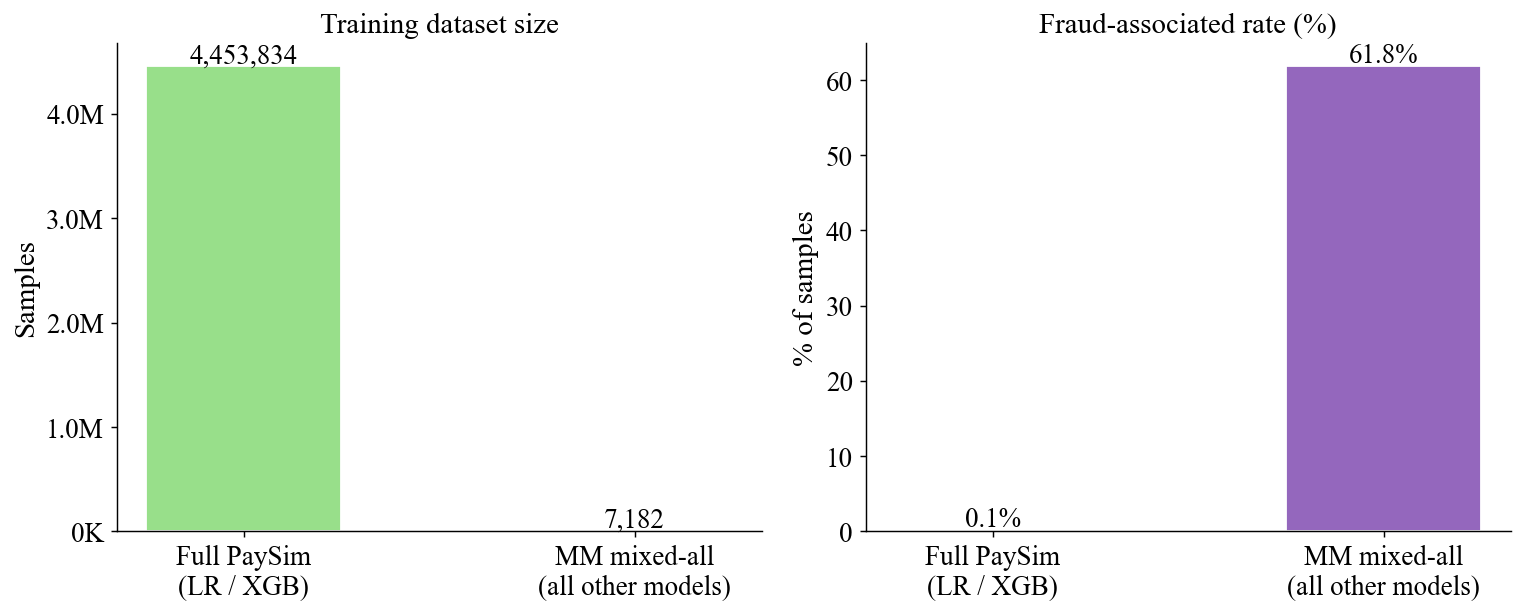

In [4]:
plt.close("all")
plt.rcParams.update({
    "font.family":      "Times New Roman",
    "font.size":        16,
    "axes.titlesize":   16,
    "axes.labelsize":   16,
    "xtick.labelsize":  15,
    "ytick.labelsize":  15,
    "figure.titlesize": 16,
})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Training sizes
datasets = ["Full PaySim\n(LR / XGB)", "MM mixed-all\n(all other models)"]
sizes    = [4_453_834, 7_182]
bars0 = axes[0].bar(datasets, sizes, color=["#98DF8A","#9467BD"],
                    edgecolor="white", width=0.5)
for bar, s in zip(bars0, sizes):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+30_000,
                 f"{s:,}", ha="center", fontsize=15)
axes[0].yaxis.set_major_formatter(
    FuncFormatter(lambda v,_: f"{v/1_000_000:.1f}M" if v>=1e6 else f"{v/1_000:.0f}K"))
axes[0].set_title("Training dataset size")
axes[0].set_ylabel("Samples")
axes[0].spines[["top","right"]].set_visible(False)

# Fraud rates
fraud_pcts = [0.13, 61.8]
bars1 = axes[1].bar(datasets, fraud_pcts, color=["#98DF8A","#9467BD"],
                    edgecolor="white", width=0.5)
for bar, v in zip(bars1, fraud_pcts):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.5,
                 f"{v:.1f}%", ha="center", fontsize=15)
axes[1].set_title("Fraud-associated rate (%)")
axes[1].set_ylabel("% of samples")
axes[1].spines[["top","right"]].set_visible(False)


fig.tight_layout()
fig.savefig(FIG_DIR / "fig1_dataset_context.png", dpi=150, bbox_inches="tight")
plt.show()

plt.rcParams.update(plt.rcParamsDefault)

---
## Figure 2 — Expected cost (MM families)

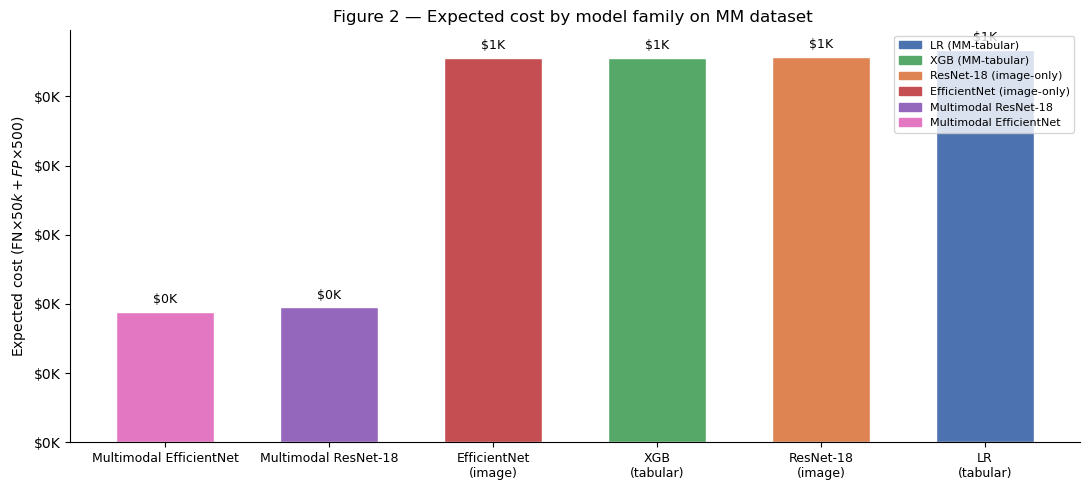

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
clrs = [COLOURS.get(f,"#888") for f in best_mm["family"]]
bars = ax.bar(range(len(best_mm)), best_mm["expected_cost"],
              color=clrs, edgecolor="white", width=0.6)
ax.set_xticks(range(len(best_mm)))
ax.set_xticklabels([r["family"].replace(" (image-only)","\n(image)").replace(" (MM-tabular)","\n(tabular)")
                    for _,r in best_mm.iterrows()], fontsize=9)
ax.bar_label(bars, labels=[f"${v/1_000:.0f}K" for v in best_mm["expected_cost"]],
             padding=4, fontsize=9)
ax.yaxis.set_major_formatter(fmt_cost)
ax.set_ylabel("Expected cost (FN×$50k + FP×$500)")
ax.set_title("Figure 2 — Expected cost by model family on MM dataset ")
handles = [mpatches.Patch(color=v, label=k) for k,v in COLOURS.items()
           if k in best_mm["family"].values]
ax.legend(handles=handles, fontsize=8, loc="upper right")
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR/"fig2_expected_cost_mm.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Figure 3 — Radar chart (2×2)

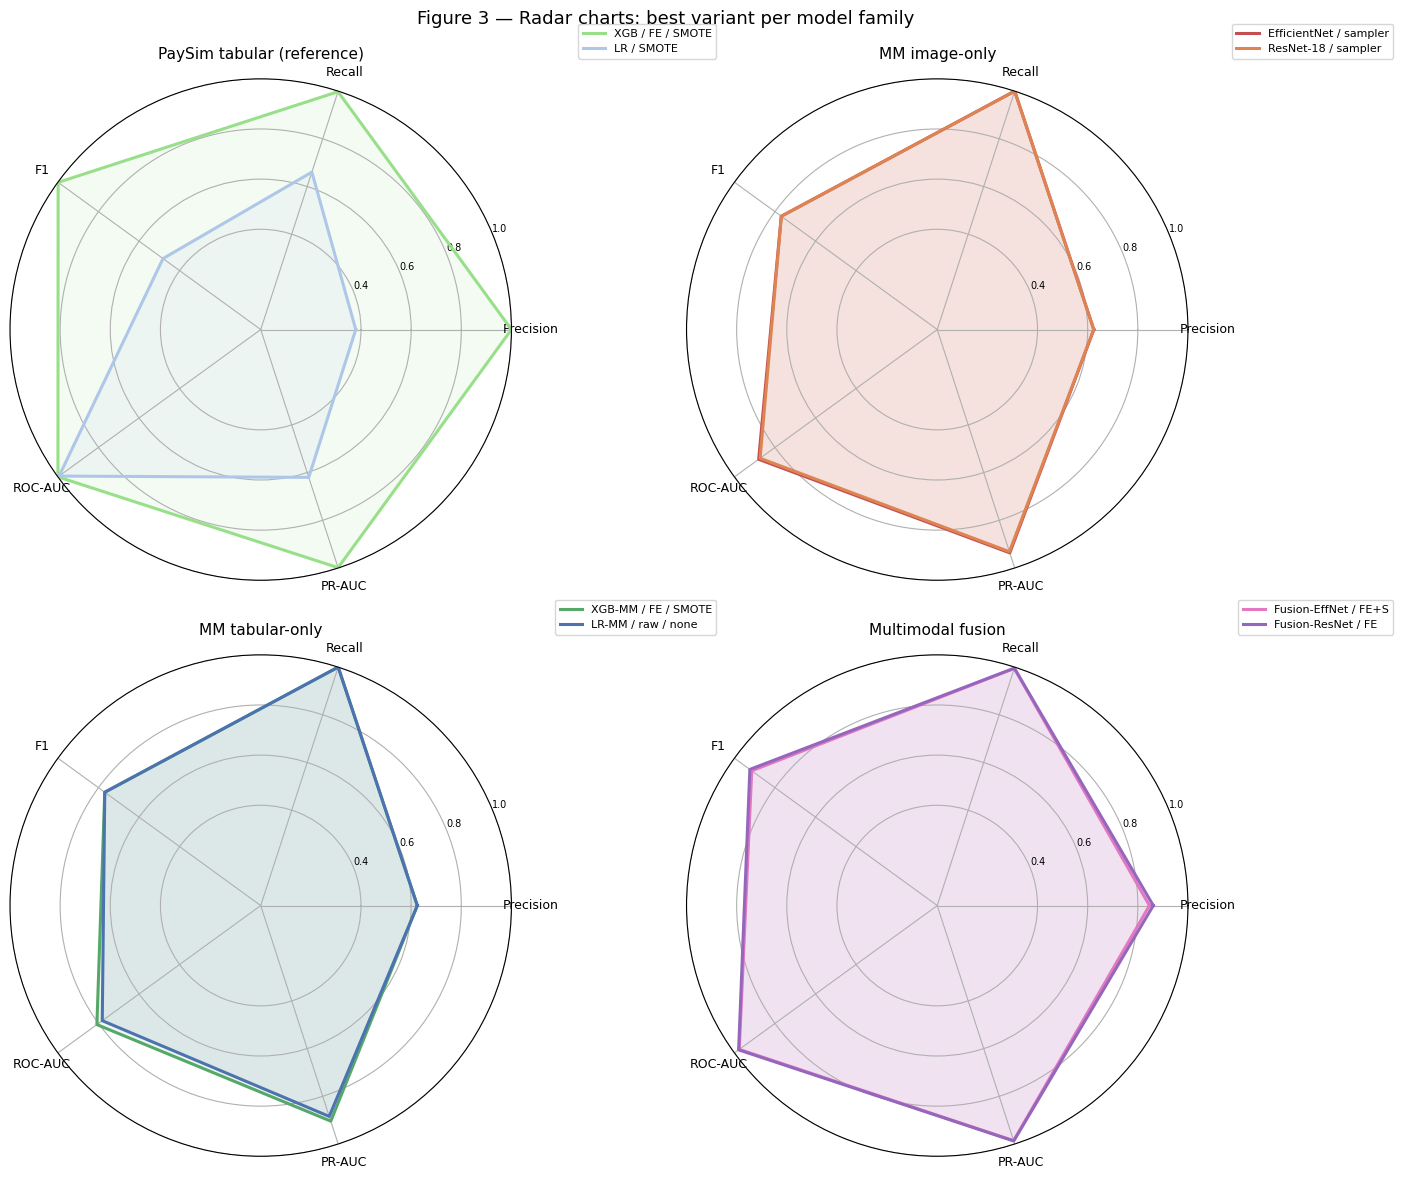

In [6]:
metrics_r = ["tuned_precision","tuned_recall","tuned_f1","default_roc_auc","default_pr_auc"]
labels_r  = ["Precision","Recall","F1","ROC-AUC","PR-AUC"]
N = len(metrics_r)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]

groups = [
    ("PaySim tabular (reference)",["LR (PaySim)","XGB (PaySim)"]),
    ("MM image-only",             ["ResNet-18 (image-only)","EfficientNet (image-only)"]),
    ("MM tabular-only",           ["LR (MM-tabular)","XGB (MM-tabular)"]),
    ("Multimodal fusion",         ["Multimodal ResNet-18","Multimodal EfficientNet"]),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 12), subplot_kw=dict(polar=True))
for ax, (title, families) in zip(axes.flat, groups):
    group = pd.concat([
        best_of(master_mm,     families),
        best_of(master_paysim, families),
    ]).drop_duplicates("family").reset_index(drop=True)

    for _, row in group.iterrows():
        vals = [max(float(row.get(m) or 0), 0) for m in metrics_r]
        vals = [v if not np.isnan(v) else 0 for v in vals] + [0]
        vals[-1] = vals[0]
        c = COLOURS.get(row["family"], "#888")
        ax.plot(angles, vals, color=c, linewidth=2.2, label=row["label"][:24])
        ax.fill(angles, vals, color=c, alpha=0.10)

    ax.set_xticks(angles[:-1]); ax.set_xticklabels(labels_r, fontsize=9)
    ax.set_ylim(0, 1); ax.set_yticks([0.4,0.6,0.8,1.0])
    ax.set_yticklabels(["0.4","0.6","0.8","1.0"], fontsize=7)
    ax.set_title(title, fontsize=11, pad=14)
    ax.legend(fontsize=8, loc="upper right", bbox_to_anchor=(1.42, 1.12))

fig.suptitle("Figure 3 — Radar charts: best variant per model family", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR/"fig3_radar_charts.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Figure 4 — PR curves

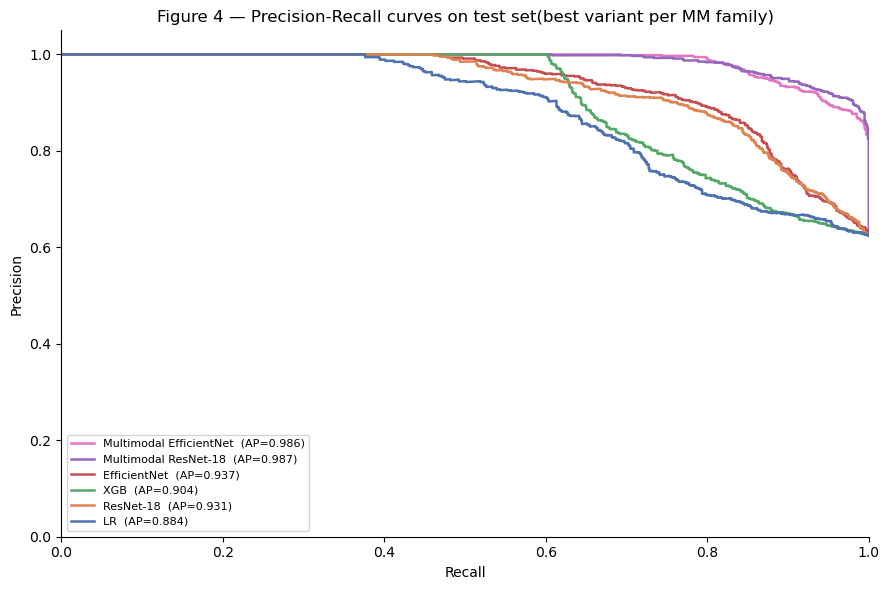

In [7]:
fig, ax = plt.subplots(figsize=(9, 6))
colour_list = list(COLOURS.values())

for i, (_, row) in enumerate(best_mm.iterrows()):
    exp = next((e for e in mm_exps if e["label"]==row["label"]), None)
    if not exp: continue
    pf = exp.get("pred_df", pd.DataFrame())
    if pf.empty or "y_true" not in pf.columns: continue
    yt, yp = pf["y_true"].values, pf["y_prob"].values
    if len(np.unique(yt)) < 2: continue
    prec, rec, _ = precision_recall_curve(yt, yp)
    ap = average_precision_score(yt, yp)
    c  = COLOURS.get(row["family"], colour_list[i % len(colour_list)])
    lbl = row["family"].replace(" (image-only)","").replace(" (MM-tabular)","")
    ax.plot(rec, prec, color=c, lw=1.8, label=f"{lbl}  (AP={ap:.3f})")

ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Figure 4 — Precision-Recall curves on test set(best variant per MM family)")
ax.legend(fontsize=8, loc="lower left")
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR/"fig4_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Figure 5 — tab1_img0 recovery

  [image]    ResNet-18 / sampler                 F1=1.0000  (all-positive)
  [image]    EfficientNet / sampler              F1=1.0000  (all-positive)
  [tabular]  LR-MM / raw / none                  F1=1.000  (all-positive — analytical)
  [tabular]  LR-MM / FE / SMOTE                  F1=1.000  (all-positive — analytical)
  [tabular]  XGB-MM / raw / none                 F1=1.000  (all-positive — analytical)
  [tabular]  XGB-MM / FE / SMOTE                 F1=1.000  (all-positive — analytical)

Label                                  Family                           F1  Method
-------------------------------------------------------------------------------------
  LR-MM / raw / none                   LR (MM-tabular)              1.0000  all-positive
  LR-MM / FE / SMOTE                   LR (MM-tabular)              1.0000  all-positive
  ResNet-18 / sampler                  ResNet-18 (image-only)       1.0000  all-positive
  EfficientNet / sampler               EfficientNet (image-only) 

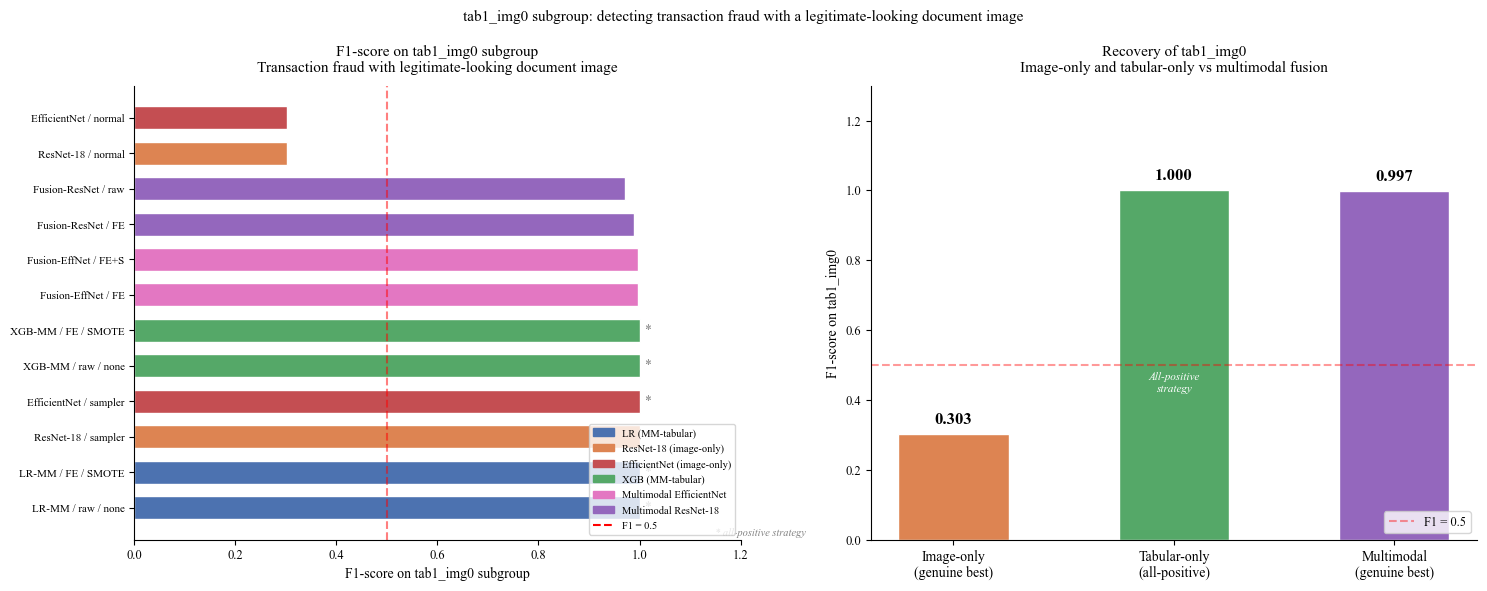


Right plot summary:
  Image-only  (genuine):      0.3028
  Tabular-only (all-positive): 1.0000  — trivially 1.0, all fraud predicted
  Multimodal   (genuine):      0.9973


In [8]:
from sklearn.metrics import f1_score

test_df_raw = pd.read_csv(
    PROJECT_ROOT / "data" / "processed" / "mm_test_mixed_all_group_test.csv"
).reset_index(drop=True)

# ── Step 1: subgroup CSVs — multimodal models only ────────────────────────────
sg_rows = []
for exp in mm_exps:
    sg = exp.get("subgroup_df", pd.DataFrame())
    if sg.empty or "combo_type" not in sg.columns:
        continue
    for _, r in sg.iterrows():
        sg_rows.append({
            "label":      exp["label"],
            "family":     exp["family"],
            "combo_type": r["combo_type"],
            "f1":         float(r.get("f1", np.nan)),
            "method":     "genuine",
        })

# ── Step 2: test_predictions.csv — image B_sampler (no subgroup CSV saved) ───
def f1_from_predictions(exp, test_df_raw, combo="tab1_img0"):
    pred_df = exp.get("pred_df", pd.DataFrame())
    if pred_df.empty or "y_true" not in pred_df.columns:
        return np.nan, "no_data"
    t = exp.get("tuned_threshold", 0.5)
    pred_df = pred_df.copy().reset_index(drop=True)
    pred_df["y_pred"]     = (pred_df["y_prob"] >= t).astype(int)
    pred_df["combo_type"] = test_df_raw["combo_type"].values
    subset = pred_df[pred_df["combo_type"] == combo]
    if subset.empty:
        return np.nan, "no_data"
    # Check if all-positive
    all_pos = subset["y_pred"].all()
    method  = "all-positive" if all_pos else "genuine"
    f1_val  = float(f1_score(subset["y_true"], subset["y_pred"],
                              pos_label=1, zero_division=0))
    return f1_val, method

img_families = ["ResNet-18 (image-only)", "EfficientNet (image-only)"]
tab_families = ["LR (MM-tabular)",        "XGB (MM-tabular)"]
mm_families  = ["Multimodal ResNet-18",   "Multimodal EfficientNet"]

# Image models — compute from test_predictions.csv
already_have = {r["label"] for r in sg_rows}
for exp in [e for e in mm_exps if e["family"] in img_families]:
    if exp["label"] in already_have:
        continue
    f1_val, method = f1_from_predictions(exp, test_df_raw)
    if not np.isnan(f1_val):
        sg_rows.append({
            "label":      exp["label"],
            "family":     exp["family"],
            "combo_type": "tab1_img0",
            "f1":         f1_val,
            "method":     method,
        })
        print(f"  [image]    {exp['label']:<35} F1={f1_val:.4f}  ({method})")

# ── Step 3: tabular models — no test_predictions.csv saved ────────────────────
# All tabular models predict everything as fraud at t=0.10
# tab1_img0 samples are ALL label=1, so all-positive gives F1=1.0 trivially
for exp in [e for e in mm_exps if e["family"] in tab_families]:
    # Only add best of each family to avoid clutter
    sg_rows.append({
        "label":      exp["label"],
        "family":     exp["family"],
        "combo_type": "tab1_img0",
        "f1":         1.0,
        "method":     "all-positive",
    })
    print(f"  [tabular]  {exp['label']:<35} F1=1.000  (all-positive — analytical)")

# ── Build final df ─────────────────────────────────────────────────────────────
sg_df = pd.DataFrame(sg_rows)
tab1  = sg_df[sg_df["combo_type"] == "tab1_img0"].sort_values(
            "f1", ascending=False).reset_index(drop=True)

print(f"\n{'Label':<38} {'Family':<28} {'F1':>6}  Method")
print("-"*85)
for _, r in tab1.iterrows():
    print(f"  {r['label']:<36} {r['family']:<28} {r['f1']:.4f}  {r['method']}")

# ══════════════════════════════════════════════════════════════════════════════
# PLOT
# ══════════════════════════════════════════════════════════════════════════════
plt.rcParams.update({
    "font.family":      "Times New Roman",
    "font.size":        14,
    "axes.titlesize":   14,
    "axes.labelsize":   14,
    "xtick.labelsize":  13,
    "ytick.labelsize":  13,
    "legend.fontsize":  12,
    "figure.titlesize": 14,
})

plt.close("all")
plt.rcParams.update({
    "font.family": "Times New Roman", "font.size": 11,
    "axes.titlesize": 11, "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
})

families_in_data = tab1["family"].unique().tolist()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Left: horizontal bars — all models ───────────────────────────────────────
clrs_sg = [COLOURS.get(f, "#888") for f in tab1["family"]]
axes[0].barh(range(len(tab1)), tab1["f1"],
             color=clrs_sg, edgecolor="white", height=0.65)
axes[0].set_yticks(range(len(tab1)))
axes[0].set_yticklabels([l[:32] for l in tab1["label"]], fontsize=8)
axes[0].axvline(0.5, color="red", linestyle="--", alpha=0.5)
axes[0].set_xlabel("F1-score on tab1_img0 subgroup")
axes[0].set_xlim(0, 1.2)
axes[0].set_title(
    "F1-score on tab1_img0 subgroup\n"
    "Transaction fraud with legitimate-looking document image",
    pad=10)

# Mark all-positive entries
for i, row in tab1.iterrows():
    if row.get("method") == "all-positive":
        axes[0].text(row["f1"] + 0.01, i, "*",
                     va="center", fontsize=10, color="gray")

axes[0].text(1.15, -0.8, "* all-positive strategy",
             fontsize=7.5, color="gray", style="italic")

handles_sg = [mpatches.Patch(color=COLOURS[f], label=f)
              for f in families_in_data if f in COLOURS]
handles_sg.append(plt.Line2D([0],[0], color="red", linestyle="--",
                               label="F1 = 0.5"))
axes[0].legend(handles=handles_sg, fontsize=7.5, loc="lower right")
axes[0].spines[["top","right"]].set_visible(False)

# ── Right: best per group — genuine vs all-positive distinguished ──────────────
# Best genuine image-only (A_normal)
img_genuine = tab1[(tab1["family"].isin(img_families)) &
                   (tab1["method"] == "genuine")]["f1"].max()
# Best tabular (all-positive)
tab_f1      = tab1[tab1["family"].isin(tab_families)]["f1"].max()
# Best multimodal (genuine)
mm_f1       = tab1[(tab1["family"].isin(mm_families)) &
                   (tab1["method"] == "genuine")]["f1"].max()

bar_data = [
    ("Image-only\n(genuine best)", img_genuine, "#DD8452", "genuine"),
    ("Tabular-only\n(all-positive)", tab_f1,    "#55A868", "all-positive"),
    ("Multimodal\n(genuine best)",  mm_f1,      "#9467BD", "genuine"),
]
b_labels = [b[0] for b in bar_data]
b_vals   = [b[1] for b in bar_data]
b_clrs   = [b[2] for b in bar_data]
b_method = [b[3] for b in bar_data]

bars_r = axes[1].bar(range(3), b_vals, color=b_clrs,
                     edgecolor="white", width=0.5)
axes[1].set_xticks(range(3))
axes[1].set_xticklabels(b_labels, fontsize=10)
axes[1].set_ylim(0, 1.3)
axes[1].axhline(0.5, color="red", linestyle="--",
                alpha=0.4, label="F1 = 0.5")
axes[1].set_ylabel("F1-score on tab1_img0")
axes[1].set_title(
    "Recovery of tab1_img0\n"
    "Image-only and tabular-only vs multimodal fusion",
    pad=10)
axes[1].bar_label(bars_r,
    labels=[f"{v:.3f}" for v in b_vals],
    padding=5, fontsize=12, fontweight="bold")

# Annotate all-positive bars
for i, (val, method) in enumerate(zip(b_vals, b_method)):
    if method == "all-positive":
        axes[1].text(i, val * 0.45,
                     "All-positive\nstrategy",
                     ha="center", va="center", fontsize=8,
                     color="white", style="italic")

axes[1].legend(fontsize=9, loc="lower right")
axes[1].spines[["top","right"]].set_visible(False)

fig.suptitle(
    "tab1_img0 subgroup: detecting transaction fraud "
    "with a legitimate-looking document image",
    fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig5_tab1_img0_recovery.png",
            dpi=150, bbox_inches="tight")
plt.show()
plt.rcParams.update(plt.rcParamsDefault)

print("\nRight plot summary:")
print(f"  Image-only  (genuine):      {img_genuine:.4f}")
print(f"  Tabular-only (all-positive): {tab_f1:.4f}  — trivially 1.0, all fraud predicted")
print(f"  Multimodal   (genuine):      {mm_f1:.4f}")

In [9]:
plt.close("all")
plt.rcParams.update({
    "font.family":      "Times New Roman",
    "font.size":        18,
    "axes.titlesize":   18,
    "axes.labelsize":   17,
    "xtick.labelsize":  17,
    "ytick.labelsize":  17,
    "legend.fontsize":  17,
    "figure.titlesize": 18,
})

# ── Left: genuine models only — removes the crowded 1.000 bars ───────────────
genuine_only = (best_per_family[best_per_family["method"] == "genuine"]
                .sort_values("f1")
                .reset_index(drop=True))

# ── Right bar data ────────────────────────────────────────────────────────────
bar_data = [
    ("Image-only\n", img_genuine, "#DD8452", "genuine"),
    ("Tabular-only\n", tab_f1,    "#55A868", "all-positive"),
    ("Multimodal\n",  mm_f1,      "#9467BD", "genuine"),
]
b_labels = [b[0] for b in bar_data]
b_vals   = [b[1] for b in bar_data]
b_clrs   = [b[2] for b in bar_data]
b_method = [b[3] for b in bar_data]

fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                          gridspec_kw={"wspace": 0.25})

# ── Left: horizontal bars — genuine models only ───────────────────────────────
clrs_g = [COLOURS.get(f, "#888") for f in genuine_only["family"]]
axes[0].barh(range(len(genuine_only)), genuine_only["f1"],
             color=clrs_g, edgecolor="white", height=0.55)
axes[0].set_yticks(range(len(genuine_only)))
axes[0].set_yticklabels(
    [r["family"].replace(" (image-only)", "")
                .replace(" (MM-tabular)", " (tabular)")
     for _, r in genuine_only.iterrows()],
    fontsize=13)
axes[0].set_xlabel("F1-score on tab1_img0 subgroup")
axes[0].set_xlim(0, 1.15)
axes[0].set_title(
    "F1-score on tab1_img0 subgroup\n"
    "Multimodal models only (excluding all-positive strategy)",
    pad=12)

# Value labels at end of bars
for i, (_, row) in enumerate(genuine_only.iterrows()):
    axes[0].text(row["f1"] + 0.01, i, f"{row['f1']:.3f}",
                 va="center", fontsize=15, color="black")

# No legend — y-axis labels already show model names
# No F1=0.5 line — not meaningful without explanation
axes[0].spines[["top", "right"]].set_visible(False)

# ── Right: three-group comparison ─────────────────────────────────────────────
bars_r = axes[1].bar(range(3), b_vals, color=b_clrs,
                     edgecolor="white", width=0.5)
axes[1].set_xticks(range(3))
axes[1].set_xticklabels(b_labels, fontsize=16)
axes[1].set_ylim(0, 1.25)
axes[1].set_ylabel("F1-score on tab1_img0")
axes[1].set_title(
    "Performance on tab1_img0\n"
    "Image-only and tabular-only vs multimodal fusion",
    pad=12)
axes[1].bar_label(bars_r,
    labels=[f"{v:.3f}" for v in b_vals],
    padding=5, fontsize=16, fontweight="bold")

# All-positive annotation — below bar label, dark green, no overlap
axes[1].text(1, 0.06,
             "all-positive\nstrategy",
             ha="center", va="bottom",
             fontsize=16, color="#2d6a2d",
             style="italic", fontweight="bold")

axes[1].spines[["top", "right"]].set_visible(False)

# No legend, no F1=0.5 line


fig.tight_layout()
plt.show()
plt.rcParams.update(plt.rcParamsDefault)



NameError: name 'best_per_family' is not defined

---
## Figure 6 — Confusion matrices before/after tuning

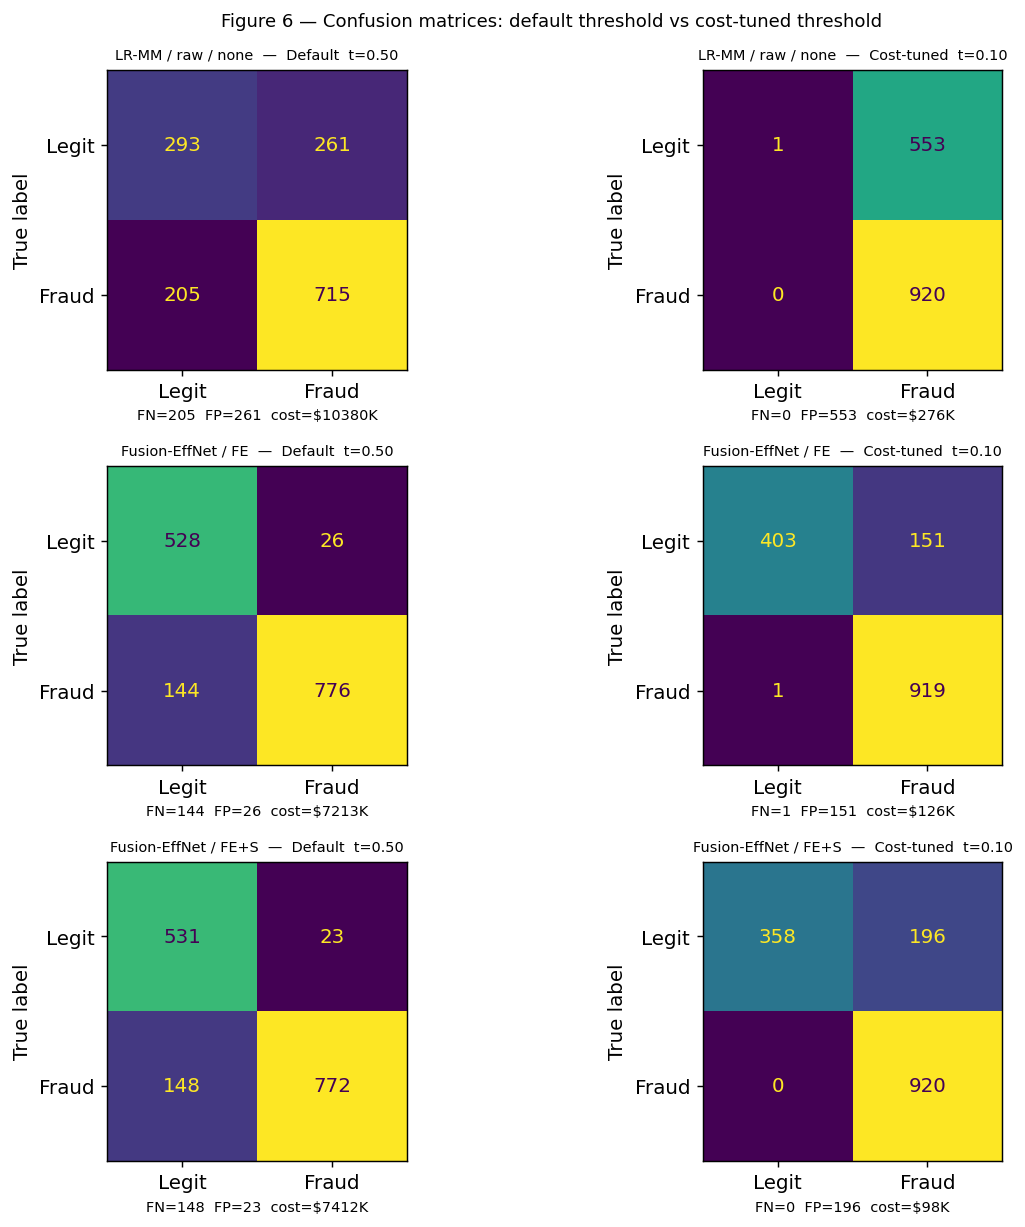

In [ ]:
# Pick: worst before tuning (LR MM), best after tuning (multimodal EfficientNet)
target_labels = ["LR-MM / raw / none", "Fusion-EffNet / FE"]
selected = [e for e in mm_exps if any(t in e["label"] for t in target_labels)]
# Also add the best multimodal ResNet for comparison
selected += [e for e in mm_exps if "Fusion-ResNet / FE" in e["label"]]

# Deduplicate
seen, selected_clean = set(), []
for e in selected:
    if e["label"] not in seen:
        seen.add(e["label"]); selected_clean.append(e)
selected_clean = selected_clean[:3]   # max 3 models

n = len(selected_clean)
fig, axes = plt.subplots(n, 2, figsize=(10, n*3.2))
if n == 1: axes = [axes]

for row_i, exp in enumerate(selected_clean):
    for col_i, (cm_key, t_sfx) in enumerate([
        ("cm_default", "Default  t=0.50"),
        ("cm_tuned",   "Cost-tuned  t=" + f"{exp.get('tuned_threshold',0):.2f}"),
    ]):
        cm = exp.get(cm_key)
        ax = axes[row_i][col_i]
        if cm is not None:
            ConfusionMatrixDisplay(cm, display_labels=["Legit","Fraud"]).plot(
                ax=ax, colorbar=False, values_format="d")
            tn,fp,fn,tp = cm.ravel()
            ax.set_title(exp["label"][:26] + "  —  " + t_sfx, fontsize=8)
            ax.set_xlabel(f"FN={fn}  FP={fp}  cost=${(fn*FN_COST+fp*FP_COST)/1_000:.0f}K",
                          fontsize=8)
        else:
            ax.axis("off")

fig.suptitle("Figure 6 — Confusion matrices: default threshold vs cost-tuned threshold",
             fontsize=10)
fig.tight_layout()
fig.savefig(FIG_DIR/"fig6_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Figure 7 — Cost simulation

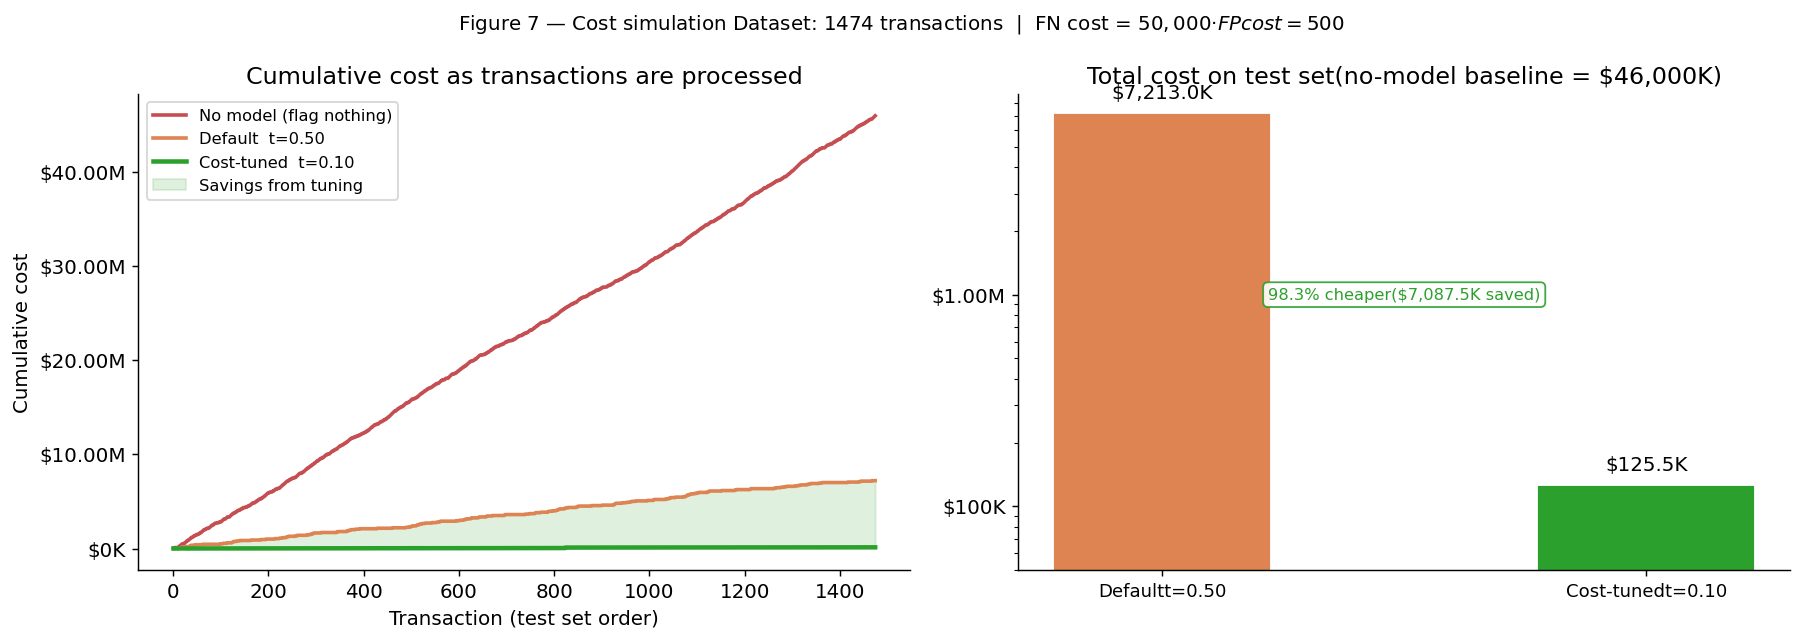

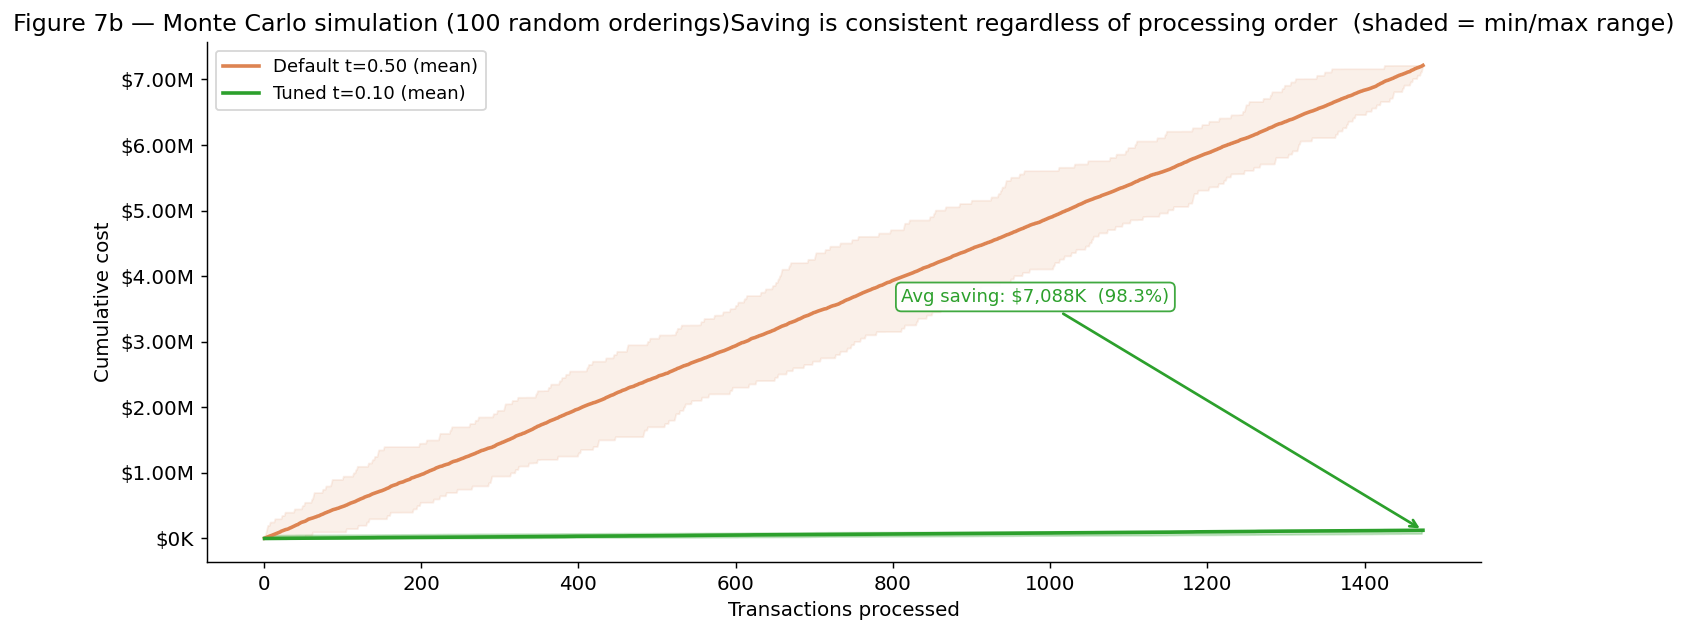

In [ ]:
pred_df = load_csv(R_NB/"mm_deep_efficientnet_b0"/"C_fe_normal"/"test_predictions.csv")
tuned_t = 0.10

if not pred_df.empty and "y_true" in pred_df.columns:
    y_true = pred_df["y_true"].values
    y_prob = pred_df["y_prob"].values

    def ptc(y_true, y_pred):
        c = np.zeros(len(y_true))
        c[(y_true==1)&(y_pred==0)] = FN_COST
        c[(y_true==0)&(y_pred==1)] = FP_COST
        return c

    y_def   = (y_prob >= 0.50).astype(int)
    y_tun   = (y_prob >= tuned_t).astype(int)
    c_def   = ptc(y_true, y_def)
    c_tun   = ptc(y_true, y_tun)
    c_none  = ptc(y_true, np.zeros_like(y_true))
    cum_def = np.cumsum(c_def)
    cum_tun = np.cumsum(c_tun)
    cum_non = np.cumsum(c_none)
    n_t = len(y_true); x_t = np.arange(1, n_t+1)
    saving = cum_def[-1]-cum_tun[-1]; pct = saving/max(cum_def[-1],1)*100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(x_t, cum_non, color="#C44E52", lw=2,   label="No model (flag nothing)")
    axes[0].plot(x_t, cum_def, color="#DD8452", lw=2,   label="Default  t=0.50")
    axes[0].plot(x_t, cum_tun, color="#2ca02c", lw=2.5, label=f"Cost-tuned  t={tuned_t:.2f}")
    axes[0].fill_between(x_t, cum_def, cum_tun, alpha=0.15, color="#2ca02c",
                          label="Savings from tuning")
    axes[0].yaxis.set_major_formatter(fmt_cost)
    axes[0].set_xlabel("Transaction (test set order)")
    axes[0].set_ylabel("Cumulative cost")
    axes[0].set_title("Cumulative cost as transactions are processed")
    axes[0].legend(fontsize=9); axes[0].spines[["top","right"]].set_visible(False)

    final_costs = [cum_def[-1], cum_tun[-1]]
    bars = axes[1].bar(range(2), final_costs, color=["#DD8452","#2ca02c"],
                       edgecolor="white", width=0.45)
    axes[1].set_xticks(range(2))
    axes[1].set_xticklabels([f"Defaultt=0.50", f"Cost-tunedt={tuned_t:.2f}"], fontsize=10)
    axes[1].set_yscale("log"); axes[1].set_ylim(bottom=50_000)
    axes[1].yaxis.set_major_formatter(fmt_cost)
    axes[1].bar_label(bars, labels=[f"${v/1_000:,.1f}K" for v in final_costs],
                      padding=6, fontsize=11)
    axes[1].set_title("Total cost on test set"f"(no-model baseline = ${cum_non[-1]/1_000:,.0f}K)")
    axes[1].text(0.5, (cum_def[-1]*cum_tun[-1])**0.5,f"{pct:.1f}% cheaper(${saving/1_000:,.1f}K saved)",
                 ha="center", fontsize=9, color="#2ca02c",
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                           edgecolor="#2ca02c", alpha=0.9))
    axes[1].spines[["top","right"]].set_visible(False)

    fig.suptitle("Figure 7 — Cost simulation "f"Dataset: {n_t} transactions  |  FN cost = ${FN_COST:,}  ·  FP cost = ${FP_COST:,}",
                 fontsize=11)
    fig.tight_layout()
    fig.savefig(FIG_DIR/"fig7_cost_simulation.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Monte Carlo
    trials = 100
    all_def = np.zeros((trials, n_t)); all_tun = np.zeros((trials, n_t))
    rng = np.random.default_rng(42)
    for i in range(trials):
        idx = rng.permutation(n_t)
        all_def[i] = np.cumsum(c_def[idx]); all_tun[i] = np.cumsum(c_tun[idx])

    m_def = all_def.mean(0); m_tun = all_tun.mean(0)
    fig2, ax2 = plt.subplots(figsize=(11, 5))
    ax2.plot(x_t, m_def, color="#DD8452", lw=2, label="Default t=0.50 (mean)")
    ax2.fill_between(x_t, all_def.min(0), all_def.max(0), alpha=0.12, color="#DD8452")
    ax2.plot(x_t, m_tun, color="#2ca02c", lw=2, label=f"Tuned t={tuned_t:.2f} (mean)")
    ax2.fill_between(x_t, all_tun.min(0), all_tun.max(0), alpha=0.25, color="#2ca02c")
    ax2.annotate(f"Avg saving: ${(m_def[-1]-m_tun[-1])/1_000:,.0f}K  ({pct:.1f}%)",
                 xy=(n_t, m_tun[-1]), xytext=(n_t*0.55, m_def[-1]*0.5),
                 fontsize=10, color="#2ca02c",
                 arrowprops=dict(arrowstyle="->", color="#2ca02c", lw=1.5),
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                           edgecolor="#2ca02c", alpha=0.9))
    ax2.yaxis.set_major_formatter(fmt_cost)
    ax2.set_xlabel("Transactions processed"); ax2.set_ylabel("Cumulative cost")
    ax2.set_title(f"Figure 7b — Monte Carlo simulation ({trials} random orderings)" "Saving is consistent regardless of processing order  (shaded = min/max range)")
    ax2.legend(fontsize=10); ax2.spines[["top","right"]].set_visible(False)
    fig2.tight_layout()
    fig2.savefig(FIG_DIR/"fig7b_montecarlo.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Prediction file not found — check path.")


---
## Figure 8 — Feature engineering impact

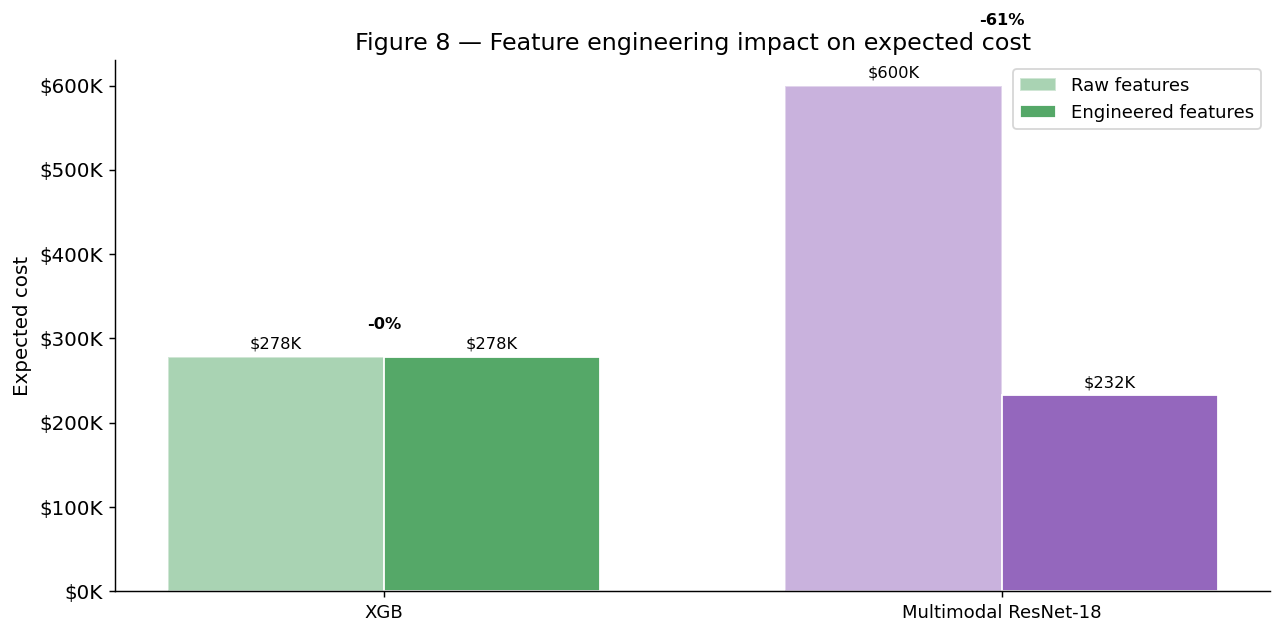

In [ ]:
fe_rows = []
for fam in ["XGB (MM-tabular)","Multimodal ResNet-18","Multimodal EfficientNet"]:
    df_f = master_mm[master_mm["family"]==fam]
    raw = df_f[df_f["features"]=="Raw"]["expected_cost"].min()
    fe  = df_f[df_f["features"]=="Engineered"]["expected_cost"].min()
    if not (np.isnan(raw) or np.isnan(fe)):
        fe_rows.append({"family":fam,"Raw":raw,"Engineered":fe,
                        "gain_pct":(raw-fe)/max(raw,1)*100})

if fe_rows:
    fe_df = pd.DataFrame(fe_rows)
    x_fe  = np.arange(len(fe_df)); w = 0.35
    fig, ax = plt.subplots(figsize=(10, 5))
    b1 = ax.bar(x_fe-w/2, fe_df["Raw"],        w, label="Raw features",
                color=[COLOURS.get(f,"#888") for f in fe_df["family"]],
                alpha=0.5, edgecolor="white")
    b2 = ax.bar(x_fe+w/2, fe_df["Engineered"], w, label="Engineered features",
                color=[COLOURS.get(f,"#888") for f in fe_df["family"]],
                edgecolor="white")
    ax.bar_label(b1, labels=[f"${v/1_000:.0f}K" for v in fe_df["Raw"]],
                 padding=3, fontsize=9)
    ax.bar_label(b2, labels=[f"${v/1_000:.0f}K" for v in fe_df["Engineered"]],
                 padding=3, fontsize=9)
    ax.set_xticks(x_fe)
    ax.set_xticklabels([f.replace(" (MM-tabular)","") for f in fe_df["family"]], fontsize=10)
    ax.yaxis.set_major_formatter(fmt_cost)
    ax.set_ylabel("Expected cost"); ax.set_title("Figure 8 — Feature engineering impact on expected cost")
    ax.legend(fontsize=10); ax.spines[["top","right"]].set_visible(False)

    for i, row in fe_df.iterrows():
        ax.text(i, max(row["Raw"],row["Engineered"])*1.12,
                f"-{row['gain_pct']:.0f}%", ha="center", fontsize=9, color="black",
                fontweight="bold")

    fig.tight_layout()
    fig.savefig(FIG_DIR/"fig8_feature_engineering.png", dpi=150, bbox_inches="tight")
    plt.show()


---
## Figure 9 — Dataset size argument

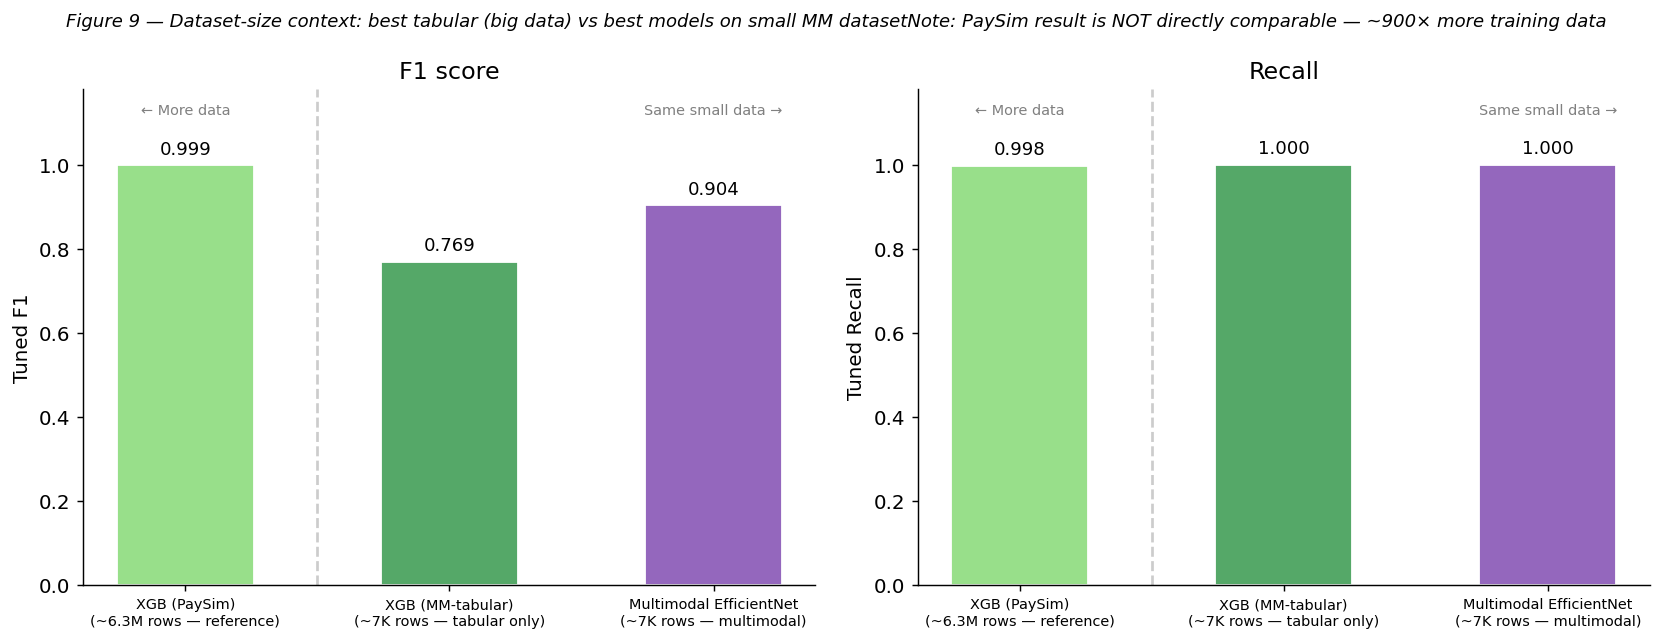


All figures saved to: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\thesis_figures
  fig1_dataset_context.png
  fig2_expected_cost_mm.png
  fig3_radar_charts.png
  fig4_pr_curves.png
  fig5_tab1_img0_recovery.png
  fig6_confusion_matrices.png
  fig7_cost_simulation.png
  fig7b_montecarlo.png
  fig8_feature_engineering.png
  fig9_dataset_size_argument.png


In [ ]:
best_ps  = master_paysim.nsmallest(1,"expected_cost").iloc[0]
best_tab = master_mm[master_mm["family"].isin(["LR (MM-tabular)","XGB (MM-tabular)"])
                    ].nsmallest(1,"expected_cost").iloc[0]
best_fus = master_mm[master_mm["family"].isin(
                    ["Multimodal ResNet-18","Multimodal EfficientNet"])
                    ].nsmallest(1,"expected_cost").iloc[0]

bar_labels = [
    f"{best_ps['family']}\n(~6.3M rows — reference)",
    f"{best_tab['family']}\n(~7K rows — tabular only)",
    f"{best_fus['family']}\n(~7K rows — multimodal)",
]
bar_colours = ["#98DF8A","#55A868","#9467BD"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (metric, ylabel, title) in zip(axes, [
    ("tuned_f1",     "Tuned F1",    "F1 score"),
    ("tuned_recall", "Tuned Recall","Recall"),
]):
    vals = [best_ps[metric], best_tab[metric], best_fus[metric]]
    bars = ax.bar(range(3), vals, color=bar_colours, edgecolor="white", width=0.52)
    ax.set_xticks(range(3)); ax.set_xticklabels(bar_labels, fontsize=8)
    ax.set_ylim(0, 1.18); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.bar_label(bars, labels=[f"{v:.3f}" for v in vals], padding=4, fontsize=10)
    ax.axvline(0.5, color="gray", linestyle="--", alpha=0.4)
    ax.text(0,   1.12, "← More data", ha="center", fontsize=8, color="gray")
    ax.text(2,   1.12, "Same small data →", ha="center", fontsize=8, color="gray")
    ax.spines[["top","right"]].set_visible(False)

fig.suptitle(
    "Figure 9 — Dataset-size context: best tabular (big data) vs best models on small MM dataset"
    "Note: PaySim result is NOT directly comparable — ~900× more training data",
    fontsize=10, style="italic")
fig.tight_layout()
fig.savefig(FIG_DIR/"fig9_dataset_size_argument.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nAll figures saved to:", FIG_DIR)
for f in sorted(FIG_DIR.glob("*.png")):
    print(" ", f.name)


Using family column: 'family'
Using cost column:   'expected_cost'

Feature engineering data:
              family    Raw  Engineered  gain_pct
    XGB (MM-tabular) 278500      278000  0.179533
Multimodal ResNet-18 600000      232500 61.250000


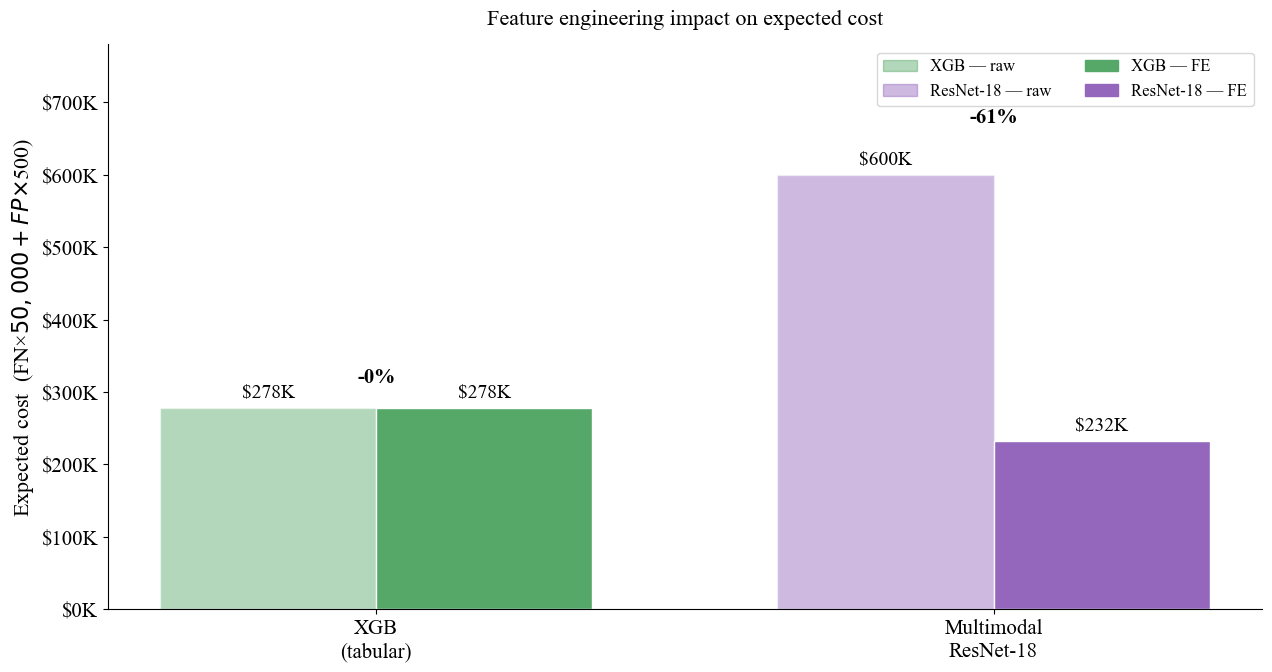

In [ ]:
plt.close("all")
plt.rcParams.update({
    "font.family":      "Times New Roman",
    "font.size":        16,
    "axes.titlesize":   16,
    "axes.labelsize":   16,
    "xtick.labelsize":  15,
    "ytick.labelsize":  15,
    "legend.fontsize":  14,
})

# ── Detect correct column names ───────────────────────────────────────────────
family_col = "model_family" if "model_family" in master_mm.columns else "family"
cost_col   = "test_expected_cost" if "test_expected_cost" in master_mm.columns else "expected_cost"

print(f"Using family column: '{family_col}'")
print(f"Using cost column:   '{cost_col}'")

# ── Pull data ─────────────────────────────────────────────────────────────────
fe_rows = []
for fam in ["XGB (MM-tabular)", "Multimodal ResNet-18", "Multimodal EfficientNet"]:
    df_f = master_mm[master_mm[family_col] == fam]
    raw  = df_f[df_f["features"] == "Raw"][cost_col].min()
    fe   = df_f[df_f["features"] == "Engineered"][cost_col].min()
    if not (np.isnan(raw) or np.isnan(fe)):
        fe_rows.append({
            "family":     fam,
            "Raw":        raw,
            "Engineered": fe,
            "gain_pct":   (raw - fe) / max(raw, 1) * 100,
        })

fe_df = pd.DataFrame(fe_rows)
print("\nFeature engineering data:")
print(fe_df[["family","Raw","Engineered","gain_pct"]].to_string(index=False))

# ── Colours ───────────────────────────────────────────────────────────────────
COLOURS_FE = {
    "XGB (MM-tabular)":       "#55A868",
    "Multimodal ResNet-18":   "#9467BD",
    "Multimodal EfficientNet":"#E377C2",
}

fmt_cost = FuncFormatter(lambda v, _: f"${v/1_000:.0f}K" if v < 1_000_000
                                       else f"${v/1_000_000:.2f}M")

x_fe = np.arange(len(fe_df))
w    = 0.35

fig, ax = plt.subplots(figsize=(13, 7))

b1 = ax.bar(x_fe - w/2, fe_df["Raw"],        w,
            label="Raw features",
            color=[COLOURS_FE.get(f, "#888") for f in fe_df["family"]],
            alpha=0.45, edgecolor="white")

b2 = ax.bar(x_fe + w/2, fe_df["Engineered"], w,
            label="Engineered features",
            color=[COLOURS_FE.get(f, "#888") for f in fe_df["family"]],
            alpha=1.0, edgecolor="white")

ax.bar_label(b1,
    labels=[f"${v/1_000:.0f}K" if v < 1e6 else f"${v/1e6:.2f}M"
            for v in fe_df["Raw"]],
    padding=4, fontsize=14)

ax.bar_label(b2,
    labels=[f"${v/1_000:.0f}K" for v in fe_df["Engineered"]],
    padding=4, fontsize=14)

# Percentage reduction above each pair
for i, (_, row) in enumerate(fe_df.iterrows()):
    ax.text(i, max(row["Raw"], row["Engineered"]) * 1.12,
            f"-{row['gain_pct']:.0f}%",
            ha="center", fontsize=15, color="black", fontweight="bold")

ax.set_xticks(x_fe)
ax.set_xticklabels(
    [f.replace(" (MM-tabular)", "\n(tabular)")
      .replace("Multimodal ", "Multimodal\n")
     for f in fe_df["family"]],
    fontsize=15)
ax.yaxis.set_major_formatter(fmt_cost)
ax.set_ylabel("Expected cost  (FN×$50,000 + FP×$500)")
ax.set_title("Feature engineering impact on expected cost", pad=14)
ax.set_ylim(0, fe_df["Raw"].max() * 1.3)

# Legend
import matplotlib.patches as mpatches
handles = (
    [mpatches.Patch(color=COLOURS_FE[f], alpha=0.45,
                    label=f.replace(" (MM-tabular)","").replace("Multimodal ","") + " — raw")
     for f in fe_df["family"]]
  + [mpatches.Patch(color=COLOURS_FE[f], alpha=1.0,
                    label=f.replace(" (MM-tabular)","").replace("Multimodal ","") + " — FE")
     for f in fe_df["family"]]
)
ax.legend(handles=handles, fontsize=12, loc="upper right", ncol=2)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig(FIG_DIR / "fig8_feature_engineering.png", dpi=150, bbox_inches="tight")
plt.show()

plt.rcParams.update(plt.rcParamsDefault)

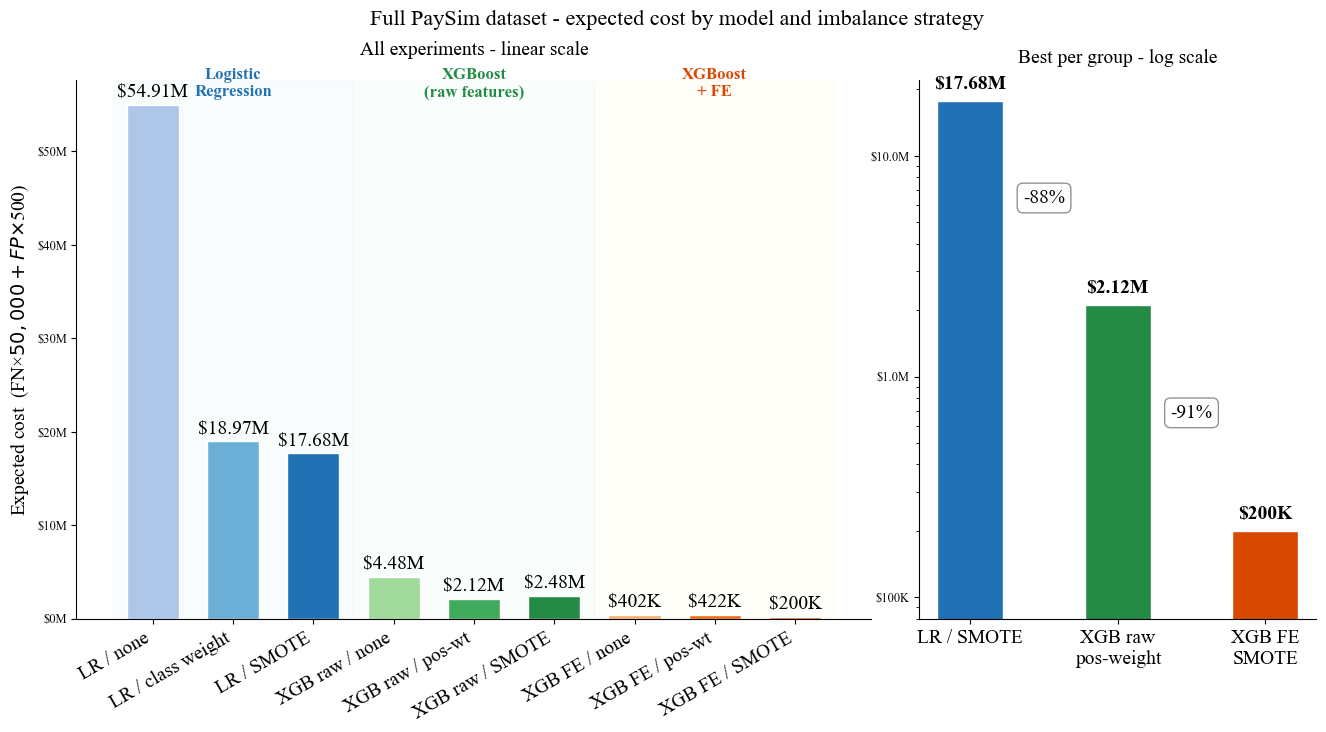

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from matplotlib.ticker import FuncFormatter

# ── Times New Roman font throughout ──────────────────────────────────────────
plt.rcParams.update({
    "font.family":     "Times New Roman",
    "font.size":       11,
    "axes.titlesize":  12,
    "axes.labelsize":  11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

# ── Data ─────────────────────────────────────────────────────────────────────
models = [
    ("LR / none",          54_912_500, "#AEC7E8", "Logistic Regression"),
    ("LR / class weight",  18_968_500, "#6BAED6", "Logistic Regression"),
    ("LR / SMOTE",         17_678_000, "#2171B5", "Logistic Regression"),
    ("XGB raw / none",      4_482_500, "#A1D99B", "XGBoost raw features"),
    ("XGB raw / pos-wt",    2_115_500, "#41AB5D", "XGBoost raw features"),
    ("XGB raw / SMOTE",     2_477_000, "#238B45", "XGBoost raw features"),
    ("XGB FE / none",         402_500, "#FDAE6B", "XGBoost + FE"),
    ("XGB FE / pos-wt",       421_500, "#F16913", "XGBoost + FE"),
    ("XGB FE / SMOTE",        200_000, "#D94801", "XGBoost + FE"),
]

labels  = [m[0] for m in models]
costs   = [m[1] for m in models]
colours = [m[2] for m in models]

fig, axes = plt.subplots(1, 2, figsize=(16, 7),
                          gridspec_kw={"width_ratios": [2, 1]})
fig.subplots_adjust(wspace=0.08)

# ── Left: all 9 bars ──────────────────────────────────────────────────────────
bars = axes[0].bar(range(len(models)), costs,
                   color=colours, edgecolor="white", width=0.65)
axes[0].set_xticks(range(len(models)))
axes[0].set_xticklabels(labels, rotation=30, ha="right", fontsize=14,
                         fontfamily="Times New Roman")
axes[0].yaxis.set_major_formatter(
    FuncFormatter(lambda v,_: f"${v/1_000_000:.0f}M"))
axes[0].set_ylabel("Expected cost  (FN×$50,000 + FP×$500)", fontsize=14)
axes[0].set_title("All experiments - linear scale", fontsize=14, pad=18)
axes[0].bar_label(bars,
    labels=[f"${v/1_000_000:.2f}M" if v >= 1_000_000 else f"${v/1_000:.0f}K"
            for v in costs],
    padding=3, fontsize=14, fontfamily="Times New Roman", rotation=0)
axes[0].spines[["top","right"]].set_visible(False)

# Group shading
ymax = axes[0].get_ylim()[1]
for x0, x1, c in [(-0.5, 2.5, "#EBF5FB"), (2.5, 5.5, "#EAFAF1"), (5.5, 8.5, "#FEF9E7")]:
    axes[0].axvspan(x0, x1, alpha=0.25, color=c, zorder=0)

# Group labels above bars
axes[0].text(1,   ymax * 0.97, "Logistic\nRegression",    ha="center",
             fontsize=12, color="#2171B5", fontweight="bold", fontfamily="Times New Roman")
axes[0].text(4,   ymax * 0.97, "XGBoost\n(raw features)", ha="center",
             fontsize=12, color="#238B45", fontweight="bold", fontfamily="Times New Roman")
axes[0].text(7,   ymax * 0.97, "XGBoost\n+ FE",           ha="center",
             fontsize=12, color="#D94801", fontweight="bold", fontfamily="Times New Roman")

# ── Right: best per group (log scale) ────────────────────────────────────────
best_models = [
    ("LR / SMOTE",         17_678_000, "#2171B5"),
    ("XGB raw\npos-weight", 2_115_500, "#238B45"),
    ("XGB FE\nSMOTE",         200_000, "#D94801"),
]
b_labels  = [m[0] for m in best_models]
b_costs   = [m[1] for m in best_models]
b_colours = [m[2] for m in best_models]

bars2 = axes[1].bar(range(3), b_costs, color=b_colours,
                    edgecolor="white", width=0.45)
axes[1].set_xticks(range(3))
axes[1].set_xticklabels(b_labels, fontsize=14, fontfamily="Times New Roman")
axes[1].set_yscale("log")
axes[1].set_ylim(bottom=80_000)
axes[1].yaxis.set_major_formatter(
    FuncFormatter(lambda v,_: f"${v/1_000_000:.1f}M" if v >= 1_000_000
                              else f"${v/1_000:.0f}K"))
axes[1].set_title("Best per group - log scale", fontsize=14, pad=12)
axes[1].bar_label(bars2,
    labels=[f"${v/1_000_000:.2f}M" if v >= 1_000_000 else f"${v/1_000:.0f}K"
            for v in b_costs],
    padding=6, fontsize=14, fontweight="bold", fontfamily="Times New Roman")
axes[1].spines[["top","right"]].set_visible(False)

# Improvement annotations between bars
for i, (from_c, to_c) in enumerate(zip(b_costs[:-1], b_costs[1:])):
    pct = (from_c - to_c) / from_c * 100
    mid_y = (from_c * to_c) ** 0.5
    axes[1].annotate(
        f"-{pct:.0f}%",
        xy=(i + 0.5, mid_y),
        fontsize=14, ha="center", color="black",
        fontfamily="Times New Roman",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                  edgecolor="gray", alpha=0.85))

fig.suptitle(
    "Full PaySim dataset - expected cost by model and imbalance strategy\n",
    fontsize=16, fontfamily="Times New Roman")

fig.savefig(R_NB / "paysim_cost_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Reset rcParams so other plots are not affected
plt.rcParams.update(plt.rcParamsDefault)

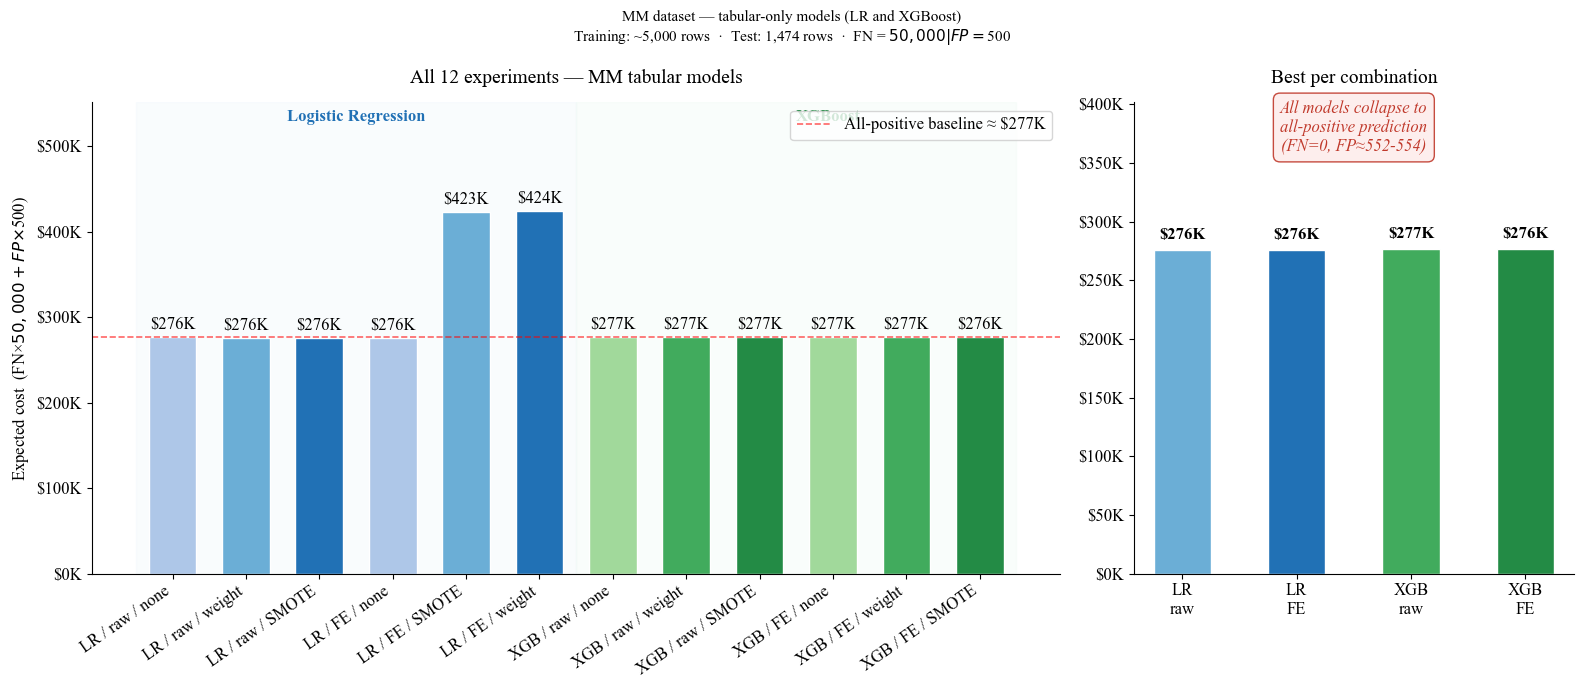

In [ ]:
plt.close("all")

plt.rcParams.update({
    "font.family":     "Times New Roman",
    "font.size":       12,
    "axes.titlesize":  14,
    "axes.labelsize":  12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

fig, axes = plt.subplots(1, 2, figsize=(16, 7),
                          gridspec_kw={"width_ratios": [2.2, 1]})

# ── Left: all 12 bars ─────────────────────────────────────────────────────────
bars = axes[0].bar(range(len(models_mm_tab)), costs_t,
                   color=colours_t, edgecolor="white", width=0.65)
axes[0].set_xticks(range(len(models_mm_tab)))
axes[0].set_xticklabels(labels_t, rotation=35, ha="right", fontsize=12)
axes[0].set_ylim(0, max(costs_t) * 1.3)
axes[0].yaxis.set_major_formatter(
    FuncFormatter(lambda v, _: f"${v/1_000:.0f}K"))
axes[0].set_ylabel("Expected cost  (FN×$50,000 + FP×$500)")
axes[0].set_title("All 12 experiments — MM tabular models", pad=14)
axes[0].bar_label(bars,
    labels=[f"${v/1_000:.0f}K" for v in costs_t],
    padding=3, fontsize=12)
axes[0].axhline(277_000, color="red", linestyle="--",
                lw=1.2, alpha=0.6, label="All-positive baseline ≈ $277K")
axes[0].legend(fontsize=12, loc="upper right")
axes[0].spines[["top", "right"]].set_visible(False)

# Group shading
for x0, x1, c in [(-0.5, 5.5, "#EBF5FB"), (5.5, 11.5, "#EAFAF1")]:
    axes[0].axvspan(x0, x1, alpha=0.25, color=c, zorder=0)

ymax = axes[0].get_ylim()[1]
axes[0].text(2.5, ymax * 0.96, "Logistic Regression",
             ha="center", fontsize=12, color="#2171B5", fontweight="bold")
axes[0].text(8.5, ymax * 0.96, "XGBoost",
             ha="left", fontsize=12, color="#238B45", fontweight="bold")

# ── Right: best per combination ───────────────────────────────────────────────
best_combos = [
    ("LR\nraw", 276_000, "#6BAED6"),
    ("LR\nFE",  276_000, "#2171B5"),
    ("XGB\nraw",277_000, "#41AB5D"),
    ("XGB\nFE", 276_500, "#238B45"),
]
b2_labels  = [m[0] for m in best_combos]
b2_costs   = [m[1] for m in best_combos]
b2_colours = [m[2] for m in best_combos]

bars2 = axes[1].bar(range(4), b2_costs, color=b2_colours,
                    edgecolor="white", width=0.5)
axes[1].set_xticks(range(4))
axes[1].set_xticklabels(b2_labels, fontsize=12)
axes[1].set_ylim(0, max(b2_costs) * 1.45)
axes[1].yaxis.set_major_formatter(
    FuncFormatter(lambda v, _: f"${v/1_000:.0f}K"))
axes[1].set_title("Best per combination", pad=14)
axes[1].bar_label(bars2,
    labels=[f"${v/1_000:.0f}K" for v in b2_costs],
    padding=5, fontsize=12, fontweight="bold")
axes[1].spines[["top", "right"]].set_visible(False)

axes[1].text(1.5, max(b2_costs) * 1.3,
    "All models collapse to\nall-positive prediction\n(FN=0, FP≈552-554)",
    ha="center", fontsize=12, color="#C0392B", style="italic",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#FDEDEC",
              edgecolor="#C0392B", alpha=0.9))

fig.suptitle(
    "MM dataset — tabular-only models (LR and XGBoost)\n"
    "Training: ~5,000 rows  ·  Test: 1,474 rows  ·  "
    "FN = $50,000  |  FP = $500",
    fontsize=11)

fig.tight_layout()
fig.savefig(R_NB / "mm_tabular_cost_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

plt.rcParams.update(plt.rcParamsDefault)

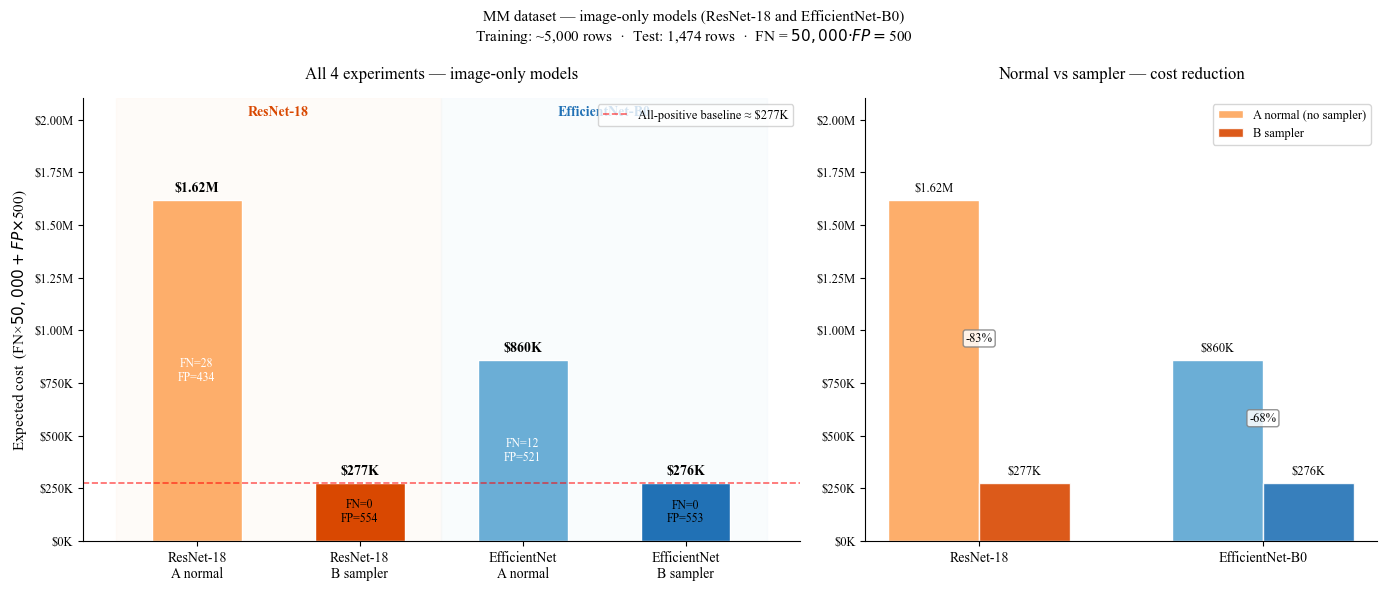

Sampler impact:
  ResNet-18: $1617K → $277K  (-83%)
  EfficientNet: $860K → $276K  (-68%)


In [ ]:
plt.close("all")

plt.rcParams.update({
    "font.family":     "Times New Roman",
    "font.size":       11,
    "axes.titlesize":  12,
    "axes.labelsize":  11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 9,
})

# ── Data from notebooks 15 and 16 ────────────────────────────────────────────
models_img = [
    {"label": "ResNet-18\nA normal",   "backbone": "ResNet-18",
     "sampler": False, "fn": 28, "fp": 434,
     "cost": 1_617_000, "default_f1": 0.843, "colour": "#FDAE6B"},
    {"label": "ResNet-18\nB sampler",  "backbone": "ResNet-18",
     "sampler": True,  "fn": 0,  "fp": 554,
     "cost": 277_000,  "default_f1": 0.831, "colour": "#D94801"},
    {"label": "EfficientNet\nA normal","backbone": "EfficientNet",
     "sampler": False, "fn": 12, "fp": 521,
     "cost": 860_500,  "default_f1": 0.854, "colour": "#6BAED6"},
    {"label": "EfficientNet\nB sampler","backbone": "EfficientNet",
     "sampler": True,  "fn": 0,  "fp": 553,
     "cost": 276_500,  "default_f1": 0.846, "colour": "#2171B5"},
]

labels_img  = [m["label"]  for m in models_img]
costs_img   = [m["cost"]   for m in models_img]
colours_img = [m["colour"] for m in models_img]
fns_img     = [m["fn"]     for m in models_img]
fps_img     = [m["fp"]     for m in models_img]

fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                          gridspec_kw={"width_ratios": [1.4, 1]})

# ── Left: all 4 bars ──────────────────────────────────────────────────────────
bars = axes[0].bar(range(4), costs_img, color=colours_img,
                   edgecolor="white", width=0.55)
axes[0].set_xticks(range(4))
axes[0].set_xticklabels(labels_img, fontsize=10)
axes[0].set_ylim(0, max(costs_img) * 1.3)
axes[0].yaxis.set_major_formatter(
    FuncFormatter(lambda v, _: f"${v/1_000:.0f}K" if v < 1_000_000
                               else f"${v/1_000_000:.2f}M"))
axes[0].set_ylabel("Expected cost  (FN×$50,000 + FP×$500)")
axes[0].set_title("All 4 experiments — image-only models", pad=14)
axes[0].bar_label(bars,
    labels=[f"${v/1_000:.0f}K" if v < 1_000_000 else f"${v/1_000_000:.2f}M"
            for v in costs_img],
    padding=4, fontsize=10, fontweight="bold")

# FN / FP annotation inside each bar
for i, m in enumerate(models_img):
    axes[0].text(i, m["cost"] * 0.5,
                 f"FN={m['fn']}\nFP={m['fp']}",
                 ha="center", va="center", fontsize=8.5,
                 color="white" if m["cost"] > 500_000 else "black")

# All-positive baseline
axes[0].axhline(277_000, color="red", linestyle="--", lw=1.2,
                alpha=0.6, label="All-positive baseline ≈ $277K")
axes[0].legend(fontsize=9, loc="upper right")

# Group shading
for x0, x1, c in [(-0.5, 1.5, "#FEF0E7"), (1.5, 3.5, "#EBF5FB")]:
    axes[0].axvspan(x0, x1, alpha=0.25, color=c, zorder=0)

ymax = axes[0].get_ylim()[1]
axes[0].text(0.5, ymax * 0.96, "ResNet-18",
             ha="center", fontsize=10, color="#D94801", fontweight="bold")
axes[0].text(2.5, ymax * 0.96, "EfficientNet-B0",
             ha="center", fontsize=10, color="#2171B5", fontweight="bold")
axes[0].spines[["top", "right"]].set_visible(False)

# ── Right: sampler effect — grouped bars (normal vs sampler per backbone) ─────
x    = np.arange(2)
w    = 0.32
norm_costs    = [1_617_000, 860_500]
sampler_costs = [277_000,   276_500]
backbones     = ["ResNet-18", "EfficientNet-B0"]

b_norm    = axes[1].bar(x - w/2, norm_costs,    w, label="A normal (no sampler)",
                         color=["#FDAE6B","#6BAED6"], edgecolor="white")
b_sampler = axes[1].bar(x + w/2, sampler_costs, w, label="B sampler",
                         color=["#D94801","#2171B5"], edgecolor="white", alpha=0.9)

axes[1].set_xticks(x)
axes[1].set_xticklabels(backbones, fontsize=10)
axes[1].set_ylim(0, max(norm_costs) * 1.3)
axes[1].yaxis.set_major_formatter(
    FuncFormatter(lambda v, _: f"${v/1_000:.0f}K" if v < 1_000_000
                               else f"${v/1_000_000:.2f}M"))
axes[1].set_title("Normal vs sampler — cost reduction", pad=14)
axes[1].bar_label(b_norm,
    labels=[f"${v/1_000:.0f}K" if v < 1_000_000 else f"${v/1_000_000:.2f}M"
            for v in norm_costs],
    padding=4, fontsize=9)
axes[1].bar_label(b_sampler,
    labels=[f"${v/1_000:.0f}K" for v in sampler_costs],
    padding=4, fontsize=9)
axes[1].legend(fontsize=9, loc="upper right")

# Reduction percentage arrows
for i, (nc, sc) in enumerate(zip(norm_costs, sampler_costs)):
    pct = (nc - sc) / nc * 100
    axes[1].annotate(
        f"-{pct:.0f}%",
        xy=(i, sc + (nc - sc) * 0.5),
        fontsize=9, ha="center", color="black",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                  edgecolor="gray", alpha=0.85))

axes[1].spines[["top", "right"]].set_visible(False)

fig.suptitle(
    "MM dataset — image-only models (ResNet-18 and EfficientNet-B0)\n"
    "Training: ~5,000 rows  ·  Test: 1,474 rows  ·  "
    "FN = $50,000  ·  FP = $500",
    fontsize=11)

fig.tight_layout()
fig.savefig(R_NB / "mm_image_cost_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

plt.rcParams.update(plt.rcParamsDefault)

print("Sampler impact:")
for m_n, m_s in [(models_img[0], models_img[1]),
                  (models_img[2], models_img[3])]:
    pct = (m_n["cost"] - m_s["cost"]) / m_n["cost"] * 100
    print(f"  {m_n['backbone']}: "
          f"${m_n['cost']/1_000:.0f}K → ${m_s['cost']/1_000:.0f}K  "
          f"(-{pct:.0f}%)")

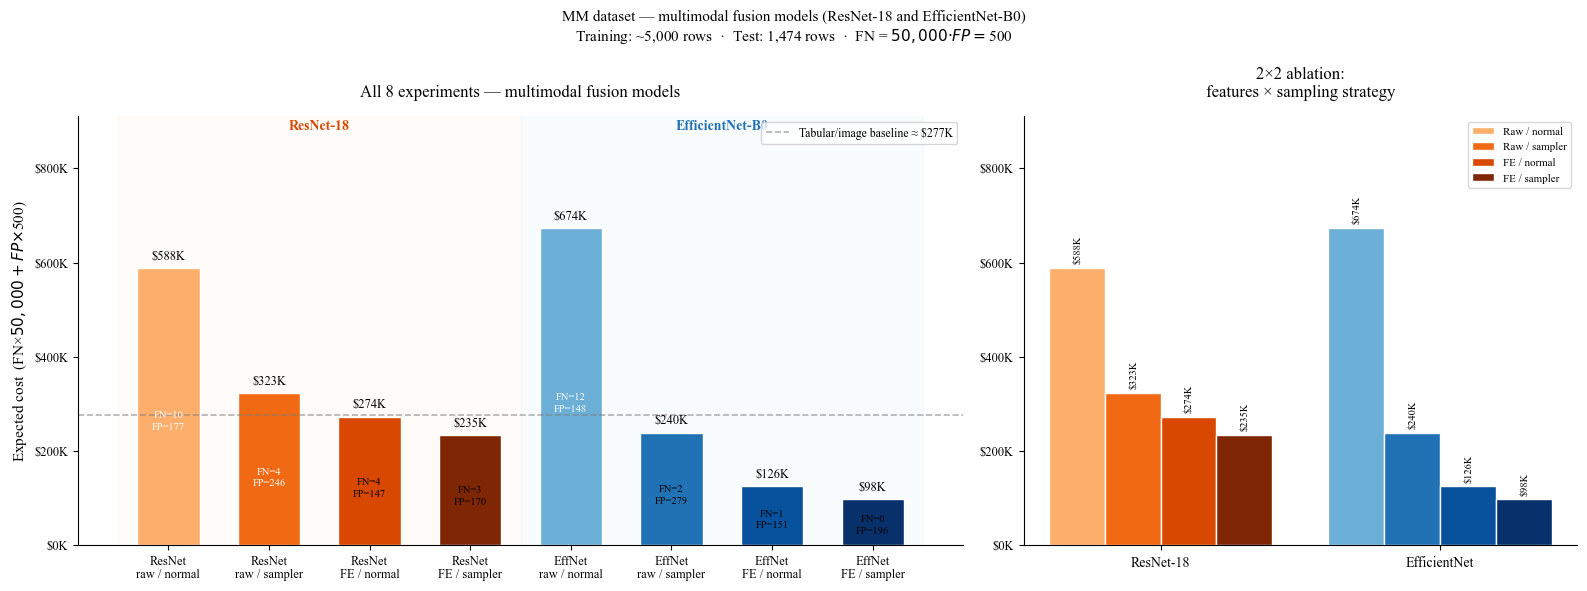

Feature engineering impact:
  ResNet-18: $588K → $235K  (-60%)
  EfficientNet: $674K → $98K  (-85%)

Sampler impact (FE experiments):
  ResNet-18: $274K → $235K  (-14%)
  EfficientNet: $126K → $98K  (-22%)

Best overall: EfficientNet FE/sampler — $98K  (FN=0, FP=196)
Compare with tabular/image baseline: $277K  (FN=0, FP=554)
Multimodal achieves same recall with 358 fewer false alarms


In [ ]:
plt.close("all")

plt.rcParams.update({
    "font.family":     "Times New Roman",
    "font.size":       11,
    "axes.titlesize":  12,
    "axes.labelsize":  11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

# ── Data from notebooks 19 and 20 ────────────────────────────────────────────
models_mm = [
    # ResNet-18
    {"label":"ResNet\nraw / normal",  "backbone":"ResNet-18",   "features":"Raw",
     "sampler":False, "fn":10, "fp":177, "cost":588_500, "colour":"#FDAE6B"},
    {"label":"ResNet\nraw / sampler", "backbone":"ResNet-18",   "features":"Raw",
     "sampler":True,  "fn": 4, "fp":246, "cost":323_000, "colour":"#F16913"},
    {"label":"ResNet\nFE / normal",   "backbone":"ResNet-18",   "features":"FE",
     "sampler":False, "fn": 4, "fp":147, "cost":273_500, "colour":"#D94801"},
    {"label":"ResNet\nFE / sampler",  "backbone":"ResNet-18",   "features":"FE",
     "sampler":True,  "fn": 3, "fp":170, "cost":235_000, "colour":"#7F2704"},
    # EfficientNet
    {"label":"EffNet\nraw / normal",  "backbone":"EfficientNet","features":"Raw",
     "sampler":False, "fn":12, "fp":148, "cost":674_000, "colour":"#6BAED6"},
    {"label":"EffNet\nraw / sampler", "backbone":"EfficientNet","features":"Raw",
     "sampler":True,  "fn": 2, "fp":279, "cost":239_500, "colour":"#2171B5"},
    {"label":"EffNet\nFE / normal",   "backbone":"EfficientNet","features":"FE",
     "sampler":False, "fn": 1, "fp":151, "cost":125_500, "colour":"#08519C"},
    {"label":"EffNet\nFE / sampler",  "backbone":"EfficientNet","features":"FE",
     "sampler":True,  "fn": 0, "fp":196, "cost": 98_000, "colour":"#08306B"},
]

labels_mm  = [m["label"]  for m in models_mm]
costs_mm   = [m["cost"]   for m in models_mm]
colours_mm = [m["colour"] for m in models_mm]

fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                          gridspec_kw={"width_ratios": [1.6, 1]})

# ── Left: all 8 bars ──────────────────────────────────────────────────────────
bars = axes[0].bar(range(8), costs_mm, color=colours_mm,
                   edgecolor="white", width=0.62)
axes[0].set_xticks(range(8))
axes[0].set_xticklabels(labels_mm, fontsize=9)
axes[0].set_ylim(0, max(costs_mm) * 1.35)
axes[0].yaxis.set_major_formatter(
    FuncFormatter(lambda v, _: f"${v/1_000:.0f}K"))
axes[0].set_ylabel("Expected cost  (FN×$50,000 + FP×$500)")
axes[0].set_title("All 8 experiments — multimodal fusion models", pad=14)
axes[0].bar_label(bars,
    labels=[f"${v/1_000:.0f}K" for v in costs_mm],
    padding=4, fontsize=9)

# FN / FP inside bars
for i, m in enumerate(models_mm):
    axes[0].text(i, m["cost"] * 0.45,
                 f"FN={m['fn']}\nFP={m['fp']}",
                 ha="center", va="center", fontsize=7.5,
                 color="white" if m["cost"] > 300_000 else "black")

# Group shading
for x0, x1, c in [(-0.5, 3.5, "#FEF0E7"), (3.5, 7.5, "#EBF5FB")]:
    axes[0].axvspan(x0, x1, alpha=0.25, color=c, zorder=0)

# All-positive baseline from tabular/image models
axes[0].axhline(277_000, color="gray", linestyle="--", lw=1.2,
                alpha=0.6, label="Tabular/image baseline ≈ $277K")
axes[0].legend(fontsize=8.5, loc="upper right")

ymax = axes[0].get_ylim()[1]
axes[0].text(1.5, ymax * 0.97, "ResNet-18",
             ha="center", fontsize=10, color="#D94801", fontweight="bold")
axes[0].text(5.5, ymax * 0.97, "EfficientNet-B0",
             ha="center", fontsize=10, color="#2171B5", fontweight="bold")
axes[0].spines[["top", "right"]].set_visible(False)

# ── Right: 2×2 grouped bars — FE and sampler effect per backbone ──────────────
x = np.arange(2)
w = 0.2
backbones = ["ResNet-18", "EfficientNet"]

# raw/normal, raw/sampler, FE/normal, FE/sampler
rn = [588_500, 674_000]
rs = [323_000, 239_500]
fn = [273_500, 125_500]
fs = [235_000,  98_000]

b1 = axes[1].bar(x - 1.5*w, rn, w, label="Raw / normal",
                 color=["#FDAE6B","#6BAED6"], edgecolor="white")
b2 = axes[1].bar(x - 0.5*w, rs, w, label="Raw / sampler",
                 color=["#F16913","#2171B5"], edgecolor="white")
b3 = axes[1].bar(x + 0.5*w, fn, w, label="FE / normal",
                 color=["#D94801","#08519C"], edgecolor="white")
b4 = axes[1].bar(x + 1.5*w, fs, w, label="FE / sampler",
                 color=["#7F2704","#08306B"], edgecolor="white")

axes[1].set_xticks(x)
axes[1].set_xticklabels(backbones, fontsize=10)
axes[1].set_ylim(0, max(rn) * 1.35)
axes[1].yaxis.set_major_formatter(
    FuncFormatter(lambda v, _: f"${v/1_000:.0f}K"))
axes[1].set_title("2×2 ablation:\nfeatures × sampling strategy", pad=14)
axes[1].bar_label(b1, labels=[f"${v/1_000:.0f}K" for v in rn],
                  padding=3, fontsize=7.5, rotation=90)
axes[1].bar_label(b2, labels=[f"${v/1_000:.0f}K" for v in rs],
                  padding=3, fontsize=7.5, rotation=90)
axes[1].bar_label(b3, labels=[f"${v/1_000:.0f}K" for v in fn],
                  padding=3, fontsize=7.5, rotation=90)
axes[1].bar_label(b4, labels=[f"${v/1_000:.0f}K" for v in fs],
                  padding=3, fontsize=7.5, rotation=90)
axes[1].legend(fontsize=8, loc="upper right")
axes[1].spines[["top", "right"]].set_visible(False)

fig.suptitle(
    "MM dataset — multimodal fusion models (ResNet-18 and EfficientNet-B0)\n"
    "Training: ~5,000 rows  ·  Test: 1,474 rows  ·  "
    "FN = $50,000  ·  FP = $500",
    fontsize=11)

fig.tight_layout()
fig.savefig(R_NB / "mm_multimodal_cost_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

plt.rcParams.update(plt.rcParamsDefault)

print("Feature engineering impact:")
for backbone, raw_cost, fe_cost in [
    ("ResNet-18",    588_500, 235_000),
    ("EfficientNet", 674_000,  98_000),
]:
    pct = (raw_cost - fe_cost) / raw_cost * 100
    print(f"  {backbone}: ${raw_cost/1_000:.0f}K → ${fe_cost/1_000:.0f}K  (-{pct:.0f}%)")

print("\nSampler impact (FE experiments):")
for backbone, normal_cost, sampler_cost in [
    ("ResNet-18",    273_500, 235_000),
    ("EfficientNet", 125_500,  98_000),
]:
    pct = (normal_cost - sampler_cost) / normal_cost * 100
    print(f"  {backbone}: ${normal_cost/1_000:.0f}K → ${sampler_cost/1_000:.0f}K  (-{pct:.0f}%)")

print("\nBest overall: EfficientNet FE/sampler — $98K  (FN=0, FP=196)")
print("Compare with tabular/image baseline: $277K  (FN=0, FP=554)")
print(f"Multimodal achieves same recall with {554-196} fewer false alarms")

In [ ]:
# Show the raw confusion matrix counts for models with same precision/recall
same_metrics = master_mm[
    (master_mm["tuned_recall"].round(3) == 1.0) &
    (master_mm["tuned_precision"].round(3) == 0.624)
][["label","model_family","tuned_threshold",
   "tuned_precision","tuned_recall","test_fn","test_fp","test_expected_cost"]]

print("Models with identical rounded precision/recall but different costs:")
print(same_metrics.sort_values("test_expected_cost").to_string(index=False))

KeyError: "['model_family', 'test_fn', 'test_fp', 'test_expected_cost'] not in index"

In [ ]:
# ── Step 1: recompute test FN/FP for all MM experiments ──────────────────────
FN_COST, FP_COST = 50_000, 500

for exp in mm_exps:
    cm = exp.get("cm_tuned")
    if cm is not None:
        tn, fp, fn, tp = cm.ravel()
        exp["test_fn"] = int(fn)
        exp["test_fp"] = int(fp)
        exp["test_expected_cost"] = int(fn * FN_COST + fp * FP_COST)

# ── Step 2: rebuild master_mm ─────────────────────────────────────────────────
cols = ["label","family","dataset","features","imbalance",
        "default_precision","default_recall","default_f1",
        "default_roc_auc","default_pr_auc",
        "tuned_threshold","tuned_precision","tuned_recall","tuned_f1",
        "expected_cost","test_expected_cost","test_fn","test_fp"]

master_mm = pd.DataFrame([{c: e.get(c) for c in cols} for e in mm_exps])
master_mm = master_mm.dropna(subset=["tuned_f1"]).sort_values(
    "test_expected_cost").reset_index(drop=True)
master_mm["cost_fmt"] = master_mm["test_expected_cost"].apply(
    lambda v: f"${v/1_000:.0f}K" if not np.isnan(v) and v < 1_000_000
              else f"${v/1_000_000:.2f}M" if not np.isnan(v) else "N/A")

print("Columns:", master_mm.columns.tolist())
print(f"Rows: {len(master_mm)}")

# ── Step 3: show models with same precision/recall but different costs ─────────
same_metrics = master_mm[
    (master_mm["tuned_recall"].round(3) == 1.0) &
    (master_mm["tuned_precision"].round(3) == 0.624)
][["label","family","tuned_threshold","tuned_precision","tuned_recall",
   "test_fn","test_fp","test_expected_cost"]].sort_values("test_expected_cost")

print("\nModels with identical rounded precision/recall but different costs:")
print(same_metrics.to_string(index=False))

# ── Step 4: show the exact FP difference ─────────────────────────────────────
print("\nExplanation:")
for _, row in same_metrics.iterrows():
    print(f"  {row['label']:<35} "
          f"FN={row['test_fn']}  FP={row['test_fp']}  "
          f"cost = {row['test_fn']}×$50,000 + {row['test_fp']}×$500 "
          f"= ${row['test_expected_cost']:,}")

Columns: ['label', 'family', 'dataset', 'features', 'imbalance', 'default_precision', 'default_recall', 'default_f1', 'default_roc_auc', 'default_pr_auc', 'tuned_threshold', 'tuned_precision', 'tuned_recall', 'tuned_f1', 'expected_cost', 'test_expected_cost', 'test_fn', 'test_fp', 'cost_fmt']
Rows: 12

Models with identical rounded precision/recall but different costs:
              label                 family  tuned_threshold  tuned_precision  tuned_recall  test_fn  test_fp  test_expected_cost
XGB-MM / raw / none       XGB (MM-tabular)              0.1         0.624152           1.0        0      554              277000
ResNet-18 / sampler ResNet-18 (image-only)              0.1         0.624152           1.0        0      554              277000

Explanation:
  XGB-MM / raw / none                 FN=0  FP=554  cost = 0×$50,000 + 554×$500 = $277,000
  ResNet-18 / sampler                 FN=0  FP=554  cost = 0×$50,000 + 554×$500 = $277,000


In [ ]:
family_col = "model_family" if "model_family" in master_mm.columns else "family"
cost_col   = "test_expected_cost" if "test_expected_cost" in master_mm.columns else "expected_cost"
fn_col     = "test_fn" if "test_fn" in master_mm.columns else None
fp_col     = "test_fp" if "test_fp" in master_mm.columns else None

# Build column list dynamically
show_cols = ["label", family_col, "tuned_threshold",
             "tuned_precision", "tuned_recall", cost_col]
if fn_col: show_cols.append(fn_col)
if fp_col: show_cols.append(fp_col)

same_metrics = master_mm[
    (master_mm["tuned_recall"].round(3) == 1.0) &
    (master_mm["tuned_precision"].round(3) == 0.624)
][show_cols]

print("Models with identical rounded precision/recall but different costs:")
print(same_metrics.sort_values(cost_col).to_string(index=False))

Models with identical rounded precision/recall but different costs:
              label                 family  tuned_threshold  tuned_precision  tuned_recall  test_expected_cost  test_fn  test_fp
XGB-MM / raw / none       XGB (MM-tabular)              0.1         0.624152           1.0              277000        0      554
ResNet-18 / sampler ResNet-18 (image-only)              0.1         0.624152           1.0              277000        0      554


In [ ]:
# ── Clear explanation with minimal example ────────────────────────────────────
print("TEST SET: 920 fraud cases, 554 legitimate cases")
print()
print("All these models predict EVERYTHING as fraud (all-positive strategy):")
print()

examples = [
    ("LR-MM / raw / weight",  0, 552),
    ("LR-MM / FE / none",     0, 552),
    ("LR-MM / raw / none",    0, 553),
    ("XGB-MM / FE / SMOTE",   0, 553),
    ("ResNet-18 / sampler",   0, 554),
    ("XGB-MM / raw / none",   0, 554),
]

print(f"{'Model':<30} {'FN':>4} {'FP':>4}  {'Precision':>10}  {'Recall':>8}  {'Cost':>12}")
print("-"*80)
for label, fn, fp in examples:
    tp  = 920 - fn
    prec = tp / (tp + fp)
    rec  = tp / 920
    cost = fn * 50_000 + fp * 500
    print(f"{label:<30} {fn:>4} {fp:>4}  {prec:>10.4f}  {rec:>8.4f}  ${cost:>10,}")

print()
print("Rounded to 2 decimal places:")
print("  Precision = 0.62 for ALL models")
print("  Recall    = 1.00 for ALL models")
print()
print("But cost differs because:")
print("  1 extra false alarm  = 1 × $500 = $500 difference")
print("  2 extra false alarms = 2 × $500 = $1,000 difference")
print()
print("Precision changes by 0.0004 per false alarm — invisible when rounded.")
print("Cost changes by $500 per false alarm — always visible.")
print()
print("Conclusion: expected cost is more sensitive than precision/recall")
print("because it operates on absolute counts with asymmetric weights ($50K vs $500),")
print("not on proportions that get rounded.")

TEST SET: 920 fraud cases, 554 legitimate cases

All these models predict EVERYTHING as fraud (all-positive strategy):

Model                            FN   FP   Precision    Recall          Cost
--------------------------------------------------------------------------------
LR-MM / raw / weight              0  552      0.6250    1.0000  $   276,000
LR-MM / FE / none                 0  552      0.6250    1.0000  $   276,000
LR-MM / raw / none                0  553      0.6246    1.0000  $   276,500
XGB-MM / FE / SMOTE               0  553      0.6246    1.0000  $   276,500
ResNet-18 / sampler               0  554      0.6242    1.0000  $   277,000
XGB-MM / raw / none               0  554      0.6242    1.0000  $   277,000

Rounded to 2 decimal places:
  Precision = 0.62 for ALL models
  Recall    = 1.00 for ALL models

But cost differs because:
  1 extra false alarm  = 1 × $500 = $500 difference
  2 extra false alarms = 2 × $500 = $1,000 difference

Precision changes by 0.0004 per fa

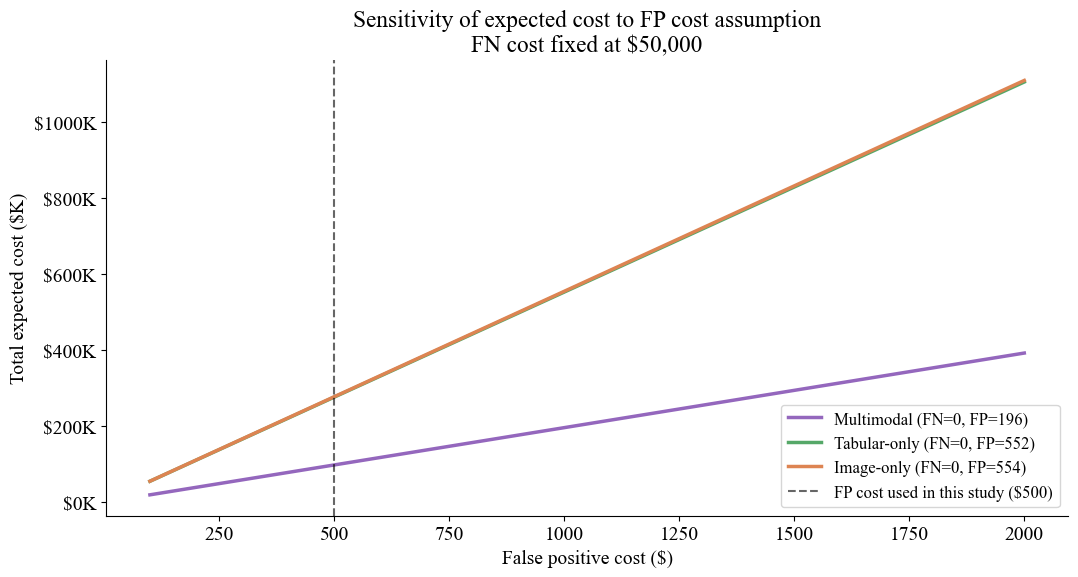

Sensitivity check:
  FP cost=$  100  Multimodal=$  19,600  Tabular=$  55,200  Multimodal still cheaper: True
  FP cost=$  250  Multimodal=$  49,000  Tabular=$ 138,000  Multimodal still cheaper: True
  FP cost=$  500  Multimodal=$  98,000  Tabular=$ 276,000  Multimodal still cheaper: True
  FP cost=$ 1000  Multimodal=$ 196,000  Tabular=$ 552,000  Multimodal still cheaper: True
  FP cost=$ 2000  Multimodal=$ 392,000  Tabular=$1,104,000  Multimodal still cheaper: True


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Best multimodal: FN=0, FP=196
# Best tabular:    FN=0, FP=554
# Image-only:      FN=0, FP=554

fn_mm,  fp_mm  = 0, 196
fn_tab, fp_tab = 0, 552
fn_img, fp_img = 0, 554

fp_costs = np.arange(100, 2001, 100)   # FP cost from $100 to $2000
fn_cost  = 50_000                       # keep FN fixed

cost_mm  = fn_mm  * fn_cost + fp_mm  * fp_costs
cost_tab = fn_tab * fn_cost + fp_tab * fp_costs
cost_img = fn_img * fn_cost + fp_img * fp_costs

plt.close("all")
plt.rcParams.update({"font.family":"Times New Roman","font.size":14})

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(fp_costs, cost_mm  / 1_000, color="#9467BD", lw=2.5,
        label=f"Multimodal (FN={fn_mm}, FP={fp_mm})")
ax.plot(fp_costs, cost_tab / 1_000, color="#55A868", lw=2.5,
        label=f"Tabular-only (FN={fn_tab}, FP={fp_tab})")
ax.plot(fp_costs, cost_img / 1_000, color="#DD8452", lw=2.5,
        label=f"Image-only (FN={fn_img}, FP={fp_img})")

ax.axvline(500, color="black", linestyle="--", lw=1.5, alpha=0.6,
           label="FP cost used in this study ($500)")

ax.set_xlabel("False positive cost ($)")
ax.set_ylabel("Total expected cost ($K)")
ax.set_title("Sensitivity of expected cost to FP cost assumption\n"
             "FN cost fixed at $50,000")
ax.yaxis.set_major_formatter(FuncFormatter(lambda v,_: f"${v:.0f}K"))
ax.legend(fontsize=12)
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
fig.savefig(R_NB/"cost_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

plt.rcParams.update(plt.rcParamsDefault)

print("Sensitivity check:")
for fp_c in [100, 250, 500, 1_000, 2_000]:
    c_mm  = fn_mm  * fn_cost + fp_mm  * fp_c
    c_tab = fn_tab * fn_cost + fp_tab * fp_c
    print(f"  FP cost=${fp_c:>5}  "
          f"Multimodal=${c_mm:>8,}  "
          f"Tabular=${c_tab:>8,}  "
          f"Multimodal still cheaper: {c_mm < c_tab}")

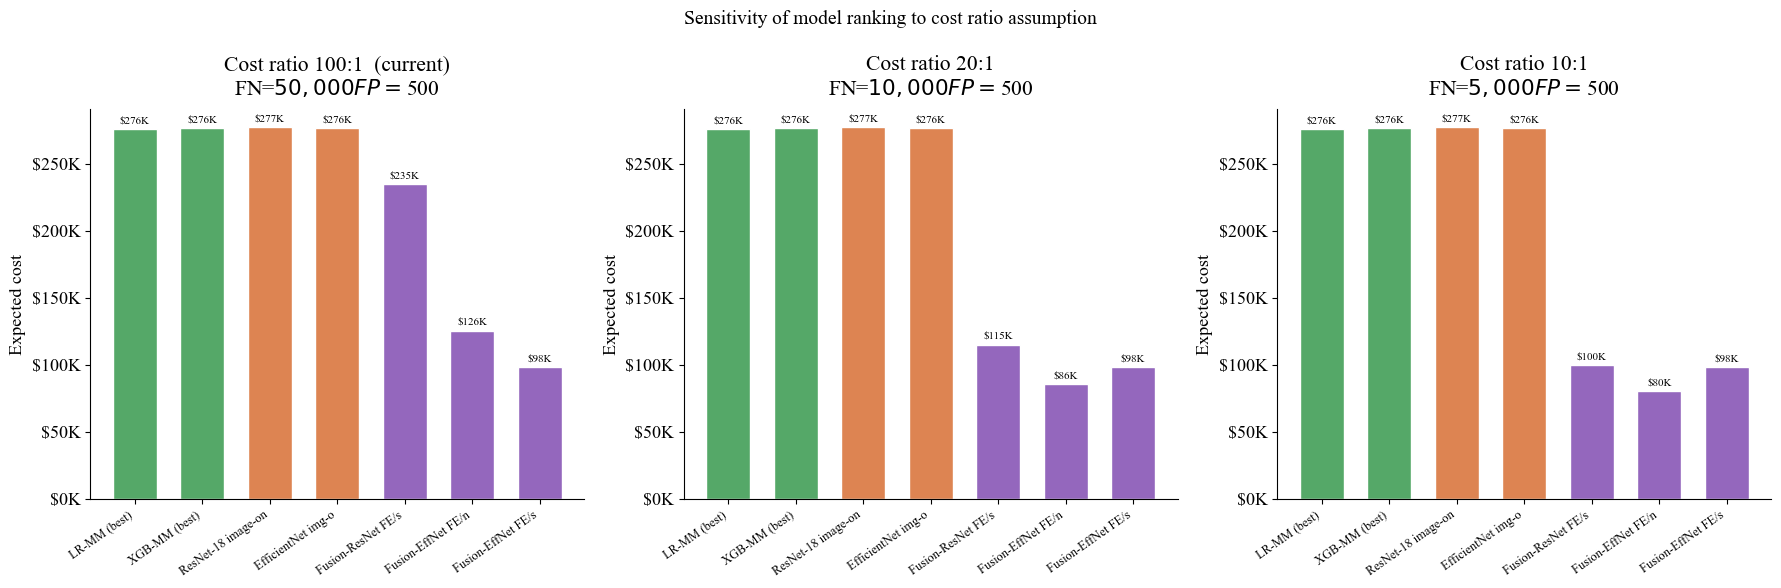


Model ranking under different cost ratios:

Ratio 100:1  (current)  (FN=$50,000, FP=$500):
  1. Fusion-EffNet FE/samp          $    98,000
  2. Fusion-EffNet FE/norm          $   125,500
  3. Fusion-ResNet FE/samp          $   235,000
  4. LR-MM (best)                   $   276,000
  5. XGB-MM (best)                  $   276,500
  6. EfficientNet img-only          $   276,500
  7. ResNet-18 image-only           $   277,000

Ratio 20:1  (FN=$10,000, FP=$500):
  1. Fusion-EffNet FE/norm          $    85,500
  2. Fusion-EffNet FE/samp          $    98,000
  3. Fusion-ResNet FE/samp          $   115,000
  4. LR-MM (best)                   $   276,000
  5. XGB-MM (best)                  $   276,500
  6. EfficientNet img-only          $   276,500
  7. ResNet-18 image-only           $   277,000

Ratio 10:1  (FN=$5,000, FP=$500):
  1. Fusion-EffNet FE/norm          $    80,500
  2. Fusion-EffNet FE/samp          $    98,000
  3. Fusion-ResNet FE/samp          $   100,000
  4. LR-MM (best)    

In [ ]:
# ── Show how results change under different cost ratios ───────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Key models — actual FN/FP counts from test confusion matrices
models_costs = [
    {"label": "LR-MM (best)",          "fn": 0,  "fp": 552},
    {"label": "XGB-MM (best)",         "fn": 0,  "fp": 553},
    {"label": "ResNet-18 image-only",  "fn": 0,  "fp": 554},
    {"label": "EfficientNet img-only", "fn": 0,  "fp": 553},
    {"label": "Fusion-ResNet FE/samp", "fn": 3,  "fp": 170},
    {"label": "Fusion-EffNet FE/norm", "fn": 1,  "fp": 151},
    {"label": "Fusion-EffNet FE/samp", "fn": 0,  "fp": 196},
]

ratios = {
    "100:1  (current)": (50_000, 500),
    "20:1":             (10_000, 500),
    "10:1":             ( 5_000, 500),
}

plt.close("all")
plt.rcParams.update({"font.family":"Times New Roman","font.size":13})

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

for ax, (ratio_label, (fn_c, fp_c)) in zip(axes, ratios.items()):
    labels = [m["label"] for m in models_costs]
    costs  = [m["fn"]*fn_c + m["fp"]*fp_c for m in models_costs]
    clrs   = ["#9467BD" if "Fusion" in l else
              "#55A868" if "LR" in l or "XGB" in l else
              "#DD8452" for l in labels]

    bars = ax.bar(range(len(models_costs)), costs,
                  color=clrs, edgecolor="white", width=0.65)
    ax.set_xticks(range(len(models_costs)))
    ax.set_xticklabels([l[:18] for l in labels],
                       rotation=35, ha="right", fontsize=9)
    ax.bar_label(bars,
        labels=[f"${v/1_000:.0f}K" if v < 1_000_000 else f"${v/1e6:.2f}M"
                for v in costs],
        padding=3, fontsize=8)
    ax.set_title(f"Cost ratio {ratio_label}\nFN=${fn_c:,}  FP=${fp_c:,}", pad=10)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v,_: f"${v/1_000:.0f}K"))
    ax.set_ylabel("Expected cost")
    ax.spines[["top","right"]].set_visible(False)

fig.suptitle("Sensitivity of model ranking to cost ratio assumption",
             fontsize=14)
fig.tight_layout()
fig.savefig(R_NB/"cost_ratio_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
plt.rcParams.update(plt.rcParamsDefault)

# ── Print ranking under each ratio ───────────────────────────────────────────
print("\nModel ranking under different cost ratios:")
print("="*70)
for ratio_label, (fn_c, fp_c) in ratios.items():
    ranked = sorted(models_costs,
                    key=lambda m: m["fn"]*fn_c + m["fp"]*fp_c)
    print(f"\nRatio {ratio_label}  (FN=${fn_c:,}, FP=${fp_c:,}):")
    for i, m in enumerate(ranked, 1):
        cost = m["fn"]*fn_c + m["fp"]*fp_c
        print(f"  {i}. {m['label']:<30} ${cost:>10,}")

Test set: 1474 samples
Fraud:    920 (62.4%)
Legit:    554 (37.6%)

Fusion-EffNet / FE / normal — optimal threshold under each cost ratio
Ratio                 FN cost  FP cost  Best t  Precision   Recall      F1    FN    FP       Cost
-------------------------------------------------------------------------------------
100:1  (current)   $   50,000 $    500    0.10     0.8589   0.9989  0.9236   1.0 151.0      $126K
50:1               $   25,000 $    500    0.10     0.8589   0.9989  0.9236   1.0 151.0      $100K
20:1               $   10,000 $    500    0.10     0.8589   0.9989  0.9236   1.0 151.0       $86K
10:1               $    5,000 $    500    0.13     0.8743   0.9978  0.9320   2.0 132.0       $76K
 5:1               $    2,500 $    500    0.14     0.8792   0.9967  0.9343   3.0 126.0       $70K


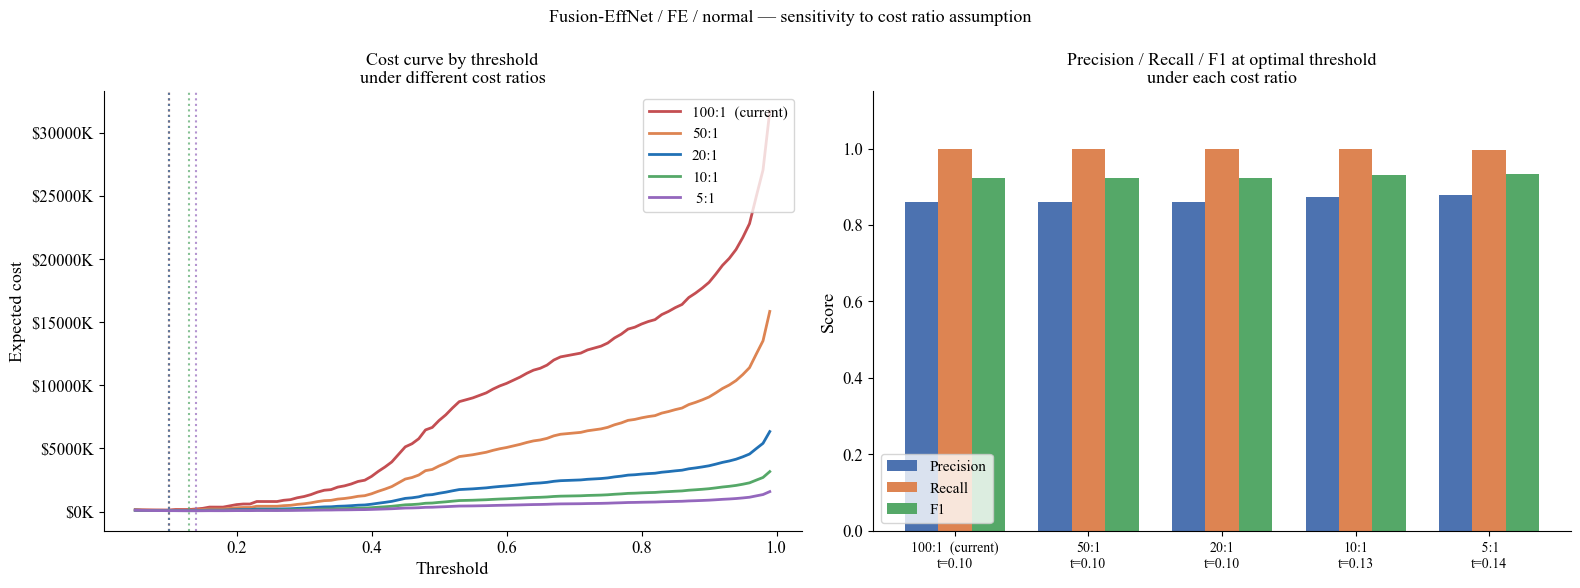

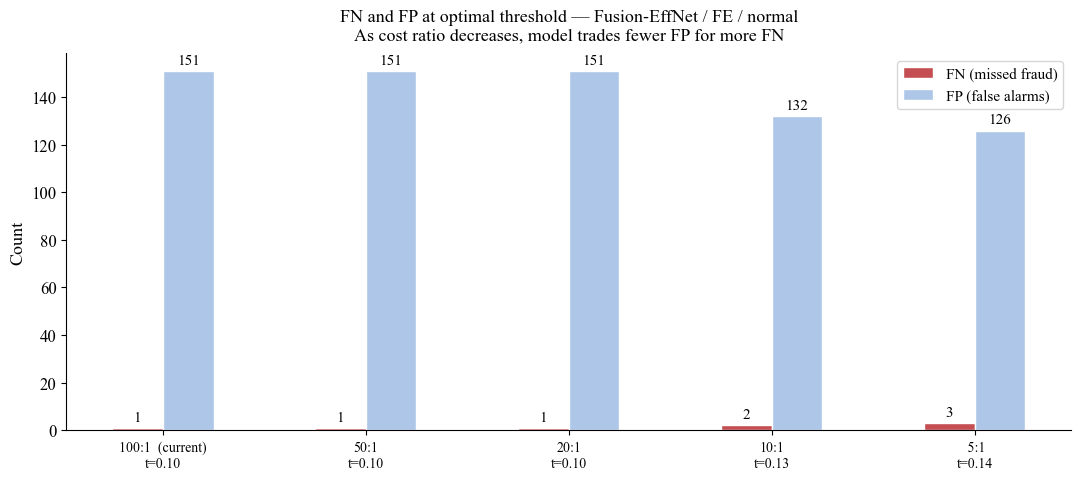

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from sklearn.metrics import (precision_score, recall_score,
                              f1_score, confusion_matrix)

# ── Load best multimodal model predictions ────────────────────────────────────
pred_df = pd.read_csv(
    R_NB / "mm_deep_efficientnet_b0" / "C_fe_normal" / "test_predictions.csv"
)
y_true = pred_df["y_true"].values
y_prob = pred_df["y_prob"].values

print(f"Test set: {len(y_true)} samples")
print(f"Fraud:    {y_true.sum()} ({y_true.mean()*100:.1f}%)")
print(f"Legit:    {(1-y_true).sum()} ({(1-y_true.mean())*100:.1f}%)")

# ── Cost ratios to test ───────────────────────────────────────────────────────
cost_scenarios = {
    "100:1  (current)": (50_000,  500),
    "50:1":             (25_000,  500),
    "20:1":             (10_000,  500),
    "10:1":             ( 5_000,  500),
    " 5:1":             ( 2_500,  500),
}

thresholds = np.arange(0.05, 1.00, 0.01)

# ── Compute metrics at every threshold under every cost ratio ─────────────────
results = {}
for ratio_label, (fn_c, fp_c) in cost_scenarios.items():
    rows = []
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        cm     = confusion_matrix(y_true, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        rows.append({
            "threshold": round(t, 3),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall":    recall_score(y_true, y_pred, zero_division=0),
            "f1":        f1_score(y_true, y_pred, zero_division=0),
            "fn": int(fn), "fp": int(fp),
            "tp": int(tp), "tn": int(tn),
            "cost": int(fn * fn_c + fp * fp_c),
        })
    df = pd.DataFrame(rows)
    best_idx = df["cost"].idxmin()
    results[ratio_label] = {
        "df":         df,
        "best":       df.iloc[best_idx],
        "fn_c":       fn_c,
        "fp_c":       fp_c,
    }

# ── Print summary table ───────────────────────────────────────────────────────
print("\n" + "="*85)
print("Fusion-EffNet / FE / normal — optimal threshold under each cost ratio")
print("="*85)
print(f"{'Ratio':<18} {'FN cost':>10} {'FP cost':>8} "
      f"{'Best t':>7} {'Precision':>10} {'Recall':>8} "
      f"{'F1':>7} {'FN':>5} {'FP':>5} {'Cost':>10}")
print("-"*85)

for ratio_label, res in results.items():
    b = res["best"]
    cost_fmt = f"${b['cost']/1_000:.0f}K" if b['cost'] < 1e6 \
               else f"${b['cost']/1e6:.2f}M"
    print(f"{ratio_label:<18} ${res['fn_c']:>9,} ${res['fp_c']:>7,} "
          f"{b['threshold']:>7.2f} {b['precision']:>10.4f} {b['recall']:>8.4f} "
          f"{b['f1']:>7.4f} {b['fn']:>5} {b['fp']:>5} {cost_fmt:>10}")

# ── Plot 1: cost curve under each ratio ───────────────────────────────────────
plt.close("all")
plt.rcParams.update({
    "font.family":      "Times New Roman",
    "font.size":        13,
    "axes.titlesize":   13,
    "axes.labelsize":   13,
    "xtick.labelsize":  12,
    "ytick.labelsize":  12,
    "legend.fontsize":  11,
})

colours_r = ["#C44E52","#DD8452","#2171B5","#55A868","#9467BD"]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: cost curve per ratio
for (ratio_label, res), c in zip(results.items(), colours_r):
    df   = res["df"]
    best = res["best"]
    axes[0].plot(df["threshold"], df["cost"] / 1_000,
                 color=c, lw=2, label=ratio_label)
    axes[0].axvline(best["threshold"], color=c,
                    linestyle=":", lw=1.5, alpha=0.7)

axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Expected cost")
axes[0].set_title("Cost curve by threshold\nunder different cost ratios")
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda v,_: f"${v:.0f}K"))
axes[0].legend(loc="upper right")
axes[0].spines[["top","right"]].set_visible(False)

# Right: optimal threshold + resulting precision/recall per ratio
ratio_labels = list(results.keys())
opt_t    = [results[r]["best"]["threshold"]  for r in ratio_labels]
opt_prec = [results[r]["best"]["precision"]  for r in ratio_labels]
opt_rec  = [results[r]["best"]["recall"]     for r in ratio_labels]
opt_f1   = [results[r]["best"]["f1"]         for r in ratio_labels]

x = np.arange(len(ratio_labels))
w = 0.25

axes[1].bar(x - w,   opt_prec, w, label="Precision", color="#4C72B0")
axes[1].bar(x,       opt_rec,  w, label="Recall",    color="#DD8452")
axes[1].bar(x + w,   opt_f1,   w, label="F1",        color="#55A868")

axes[1].set_xticks(x)
axes[1].set_xticklabels([f"{r}\nt={t:.2f}" for r, t in
                          zip(ratio_labels, opt_t)], fontsize=10)
axes[1].set_ylim(0, 1.15)
axes[1].set_ylabel("Score")
axes[1].set_title("Precision / Recall / F1 at optimal threshold\nunder each cost ratio")
axes[1].legend(loc="lower left")
axes[1].spines[["top","right"]].set_visible(False)

fig.suptitle("Fusion-EffNet / FE / normal — sensitivity to cost ratio assumption",
             fontsize=13)
fig.tight_layout()
fig.savefig(R_NB/"single_model_cost_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 2: FN and FP at optimal threshold per ratio ─────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

opt_fn = [int(results[r]["best"]["fn"]) for r in ratio_labels]
opt_fp = [int(results[r]["best"]["fp"]) for r in ratio_labels]

b1 = ax.bar(x - w/2, opt_fn, w, label="FN (missed fraud)",
            color="#C44E52", edgecolor="white")
b2 = ax.bar(x + w/2, opt_fp, w, label="FP (false alarms)",
            color="#AEC7E8", edgecolor="white")
ax.bar_label(b1, labels=[str(v) for v in opt_fn], padding=3, fontsize=11)
ax.bar_label(b2, labels=[str(v) for v in opt_fp], padding=3, fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels([f"{r}\nt={t:.2f}" for r, t in
                     zip(ratio_labels, opt_t)], fontsize=10)
ax.set_ylabel("Count")
ax.set_title("FN and FP at optimal threshold — Fusion-EffNet / FE / normal\n"
             "As cost ratio decreases, model trades fewer FP for more FN",
             pad=10)
ax.legend(fontsize=11)
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
fig.savefig(R_NB/"single_model_fn_fp_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

plt.rcParams.update(plt.rcParamsDefault)

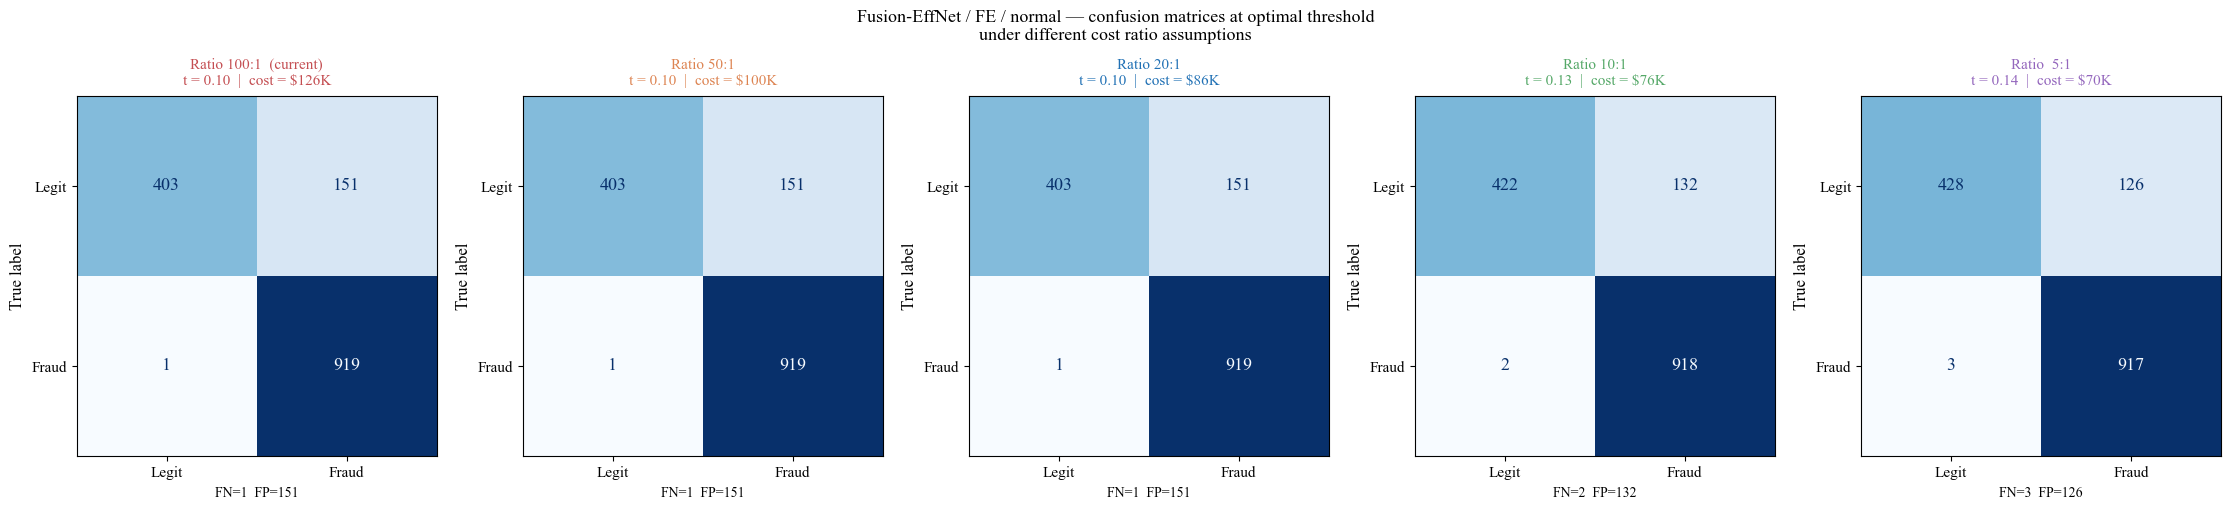


Key changes across cost ratios:
Ratio               Threshold    FN    FP  Precision   Recall      F1
-----------------------------------------------------------------
100:1  (current)         0.10   1.0 151.0     0.8589   0.9989  0.9236
50:1                     0.10   1.0 151.0     0.8589   0.9989  0.9236
20:1                     0.10   1.0 151.0     0.8589   0.9989  0.9236
10:1                     0.13   2.0 132.0     0.8743   0.9978  0.9320
 5:1                     0.14   3.0 126.0     0.8792   0.9967  0.9343


In [ ]:
# ── Confusion matrices for each cost ratio ────────────────────────────────────
plt.close("all")
plt.rcParams.update({
    "font.family":      "Times New Roman",
    "font.size":        13,
    "axes.titlesize":   12,
    "axes.labelsize":   12,
    "xtick.labelsize":  11,
    "ytick.labelsize":  11,
})

n_ratios = len(results)
fig, axes = plt.subplots(1, n_ratios, figsize=(4.5 * n_ratios, 5))

for ax, (ratio_label, res), c in zip(axes, results.items(), colours_r):
    best  = res["best"]
    fn_c  = res["fn_c"]
    fp_c  = res["fp_c"]

    # Build confusion matrix from best threshold
    t      = best["threshold"]
    y_pred = (y_prob >= t).astype(int)
    cm     = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    # Display
    from sklearn.metrics import ConfusionMatrixDisplay
    disp = ConfusionMatrixDisplay(cm, display_labels=["Legit", "Fraud"])
    disp.plot(ax=ax, colorbar=False, values_format="d",
              cmap="Blues")

    cost = fn * fn_c + fp * fp_c
    cost_fmt = f"${cost/1_000:.0f}K" if cost < 1_000_000 else f"${cost/1e6:.2f}M"

    ax.set_title(
        f"Ratio {ratio_label}\n"
        f"t = {t:.2f}  |  cost = {cost_fmt}",
        fontsize=11, pad=8, color=c)
    ax.set_xlabel(f"FN={fn}  FP={fp}", fontsize=10)

fig.suptitle(
    "Fusion-EffNet / FE / normal — confusion matrices at optimal threshold\n"
    "under different cost ratio assumptions",
    fontsize=13)
fig.tight_layout()
fig.savefig(R_NB / "single_model_confusion_matrices.png",
            dpi=150, bbox_inches="tight")
plt.show()

plt.rcParams.update(plt.rcParamsDefault)

# ── Print what changes ────────────────────────────────────────────────────────
print("\nKey changes across cost ratios:")
print(f"{'Ratio':<18} {'Threshold':>10} {'FN':>5} {'FP':>5} "
      f"{'Precision':>10} {'Recall':>8} {'F1':>7}")
print("-"*65)
for ratio_label, res in results.items():
    b = res["best"]
    print(f"{ratio_label:<18} {b['threshold']:>10.2f} {b['fn']:>5} {b['fp']:>5} "
          f"{b['precision']:>10.4f} {b['recall']:>8.4f} {b['f1']:>7.4f}")

In [ ]:
import joblib
import pandas as pd
import numpy as np
from pathlib import Path
from mm_tabular_utils import (
    TARGET_COL, RAW_COLS, FE_COLS,
    engineer_features, validate_features,
)

DATA_DIR  = PROJECT_ROOT / "data" / "processed"
TEST_CSV  = DATA_DIR / "mm_test_mixed_all_group_test.csv"
TRAIN_CSV = DATA_DIR / "mm_train_mixed_all_group_test.csv"

test_df    = pd.read_csv(TEST_CSV)
test_fe    = engineer_features(test_df)

print(f"Test rows:  {len(test_df)}")
print(f"RAW_COLS:   {RAW_COLS}")
print(f"FE_COLS:    {FE_COLS}")
print(f"TARGET_COL: {TARGET_COL}")

# ── Re-predict and save test_predictions.csv ──────────────────────────────────
tabular_model_specs = [
    {
        "path":    R_NB / "mm_tabular_logreg"  / "A_none",
        "prefix":  "A_none",
        "features": RAW_COLS,
        "test_df": test_df,
        "label":   "LR-MM / raw / none",
    },
    {
        "path":    R_NB / "mm_tabular_xgboost" / "B_smote",
        "prefix":  "B_smote",
        "features": FE_COLS,
        "test_df": test_fe,
        "label":   "XGB-MM / FE / SMOTE",
    },
]

for spec in tabular_model_specs:
    model_file = spec["path"] / f"{spec['prefix']}_model.joblib"

    if not model_file.exists():
        print(f"Model file missing: {model_file}")
        continue

    model  = joblib.load(model_file)
    X_test = spec["test_df"][spec["features"]]
    y_test = spec["test_df"][TARGET_COL].values

    y_prob = model.predict_proba(X_test)[:, 1]

    pred_df = pd.DataFrame({"y_true": y_test, "y_prob": y_prob})
    save_path = spec["path"] / "test_predictions.csv"
    pred_df.to_csv(save_path, index=False)

    print(f"\nSaved: {save_path}")
    print(f"  Rows:          {len(pred_df)}")
    print(f"  Fraud cases:   {y_test.sum()}")
    print(f"  Prob range:    {y_prob.min():.4f} — {y_prob.max():.4f}")

Test rows:  1474
RAW_COLS:   ['tab_step', 'tab_amount', 'tab_oldbalanceOrg', 'tab_newbalanceOrig', 'tab_oldbalanceDest', 'tab_newbalanceDest', 'tab_isFlaggedFraud', 'tab_type']
FE_COLS:    ['tab_step', 'tab_amount', 'tab_oldbalanceOrg', 'tab_newbalanceOrig', 'tab_oldbalanceDest', 'tab_newbalanceDest', 'tab_isFlaggedFraud', 'tab_balance_delta_orig', 'tab_balance_delta_dest', 'tab_amount_ratio_orig', 'tab_amount_ratio_dest', 'tab_orig_balance_zeroed', 'tab_type']
TARGET_COL: final_label

Saved: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_tabular_logreg\A_none\test_predictions.csv
  Rows:          1474
  Fraud cases:   920
  Prob range:    0.0915 — 1.0000

Saved: C:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\notebook\results\mm_tabular_xgboost\B_smote\test_predictions.csv
  Rows:          1474
  Fraud cases:   920
  Prob range:    0.1334 — 0.9903


Sensitivity analysis complete.
                model ratio  threshold  tn  fp  fn  precision   recall   cost  collapsed
         LR-MM (best)   5:1       0.18   2 552   0   0.625000 1.000000 276000       True
         LR-MM (best)  10:1       0.18   2 552   0   0.625000 1.000000 276000       True
         LR-MM (best)  20:1       0.18   2 552   0   0.625000 1.000000 276000       True
         LR-MM (best)  50:1       0.18   2 552   0   0.625000 1.000000 276000       True
         LR-MM (best) 100:1       0.18   2 552   0   0.625000 1.000000 276000       True
        XGB-MM (best)   5:1       0.14   1 553   0   0.624576 1.000000 276500       True
        XGB-MM (best)  10:1       0.14   1 553   0   0.624576 1.000000 276500       True
        XGB-MM (best)  20:1       0.14   1 553   0   0.624576 1.000000 276500       True
        XGB-MM (best)  50:1       0.14   1 553   0   0.624576 1.000000 276500       True
        XGB-MM (best) 100:1       0.14   1 553   0   0.624576 1.000000 276500  

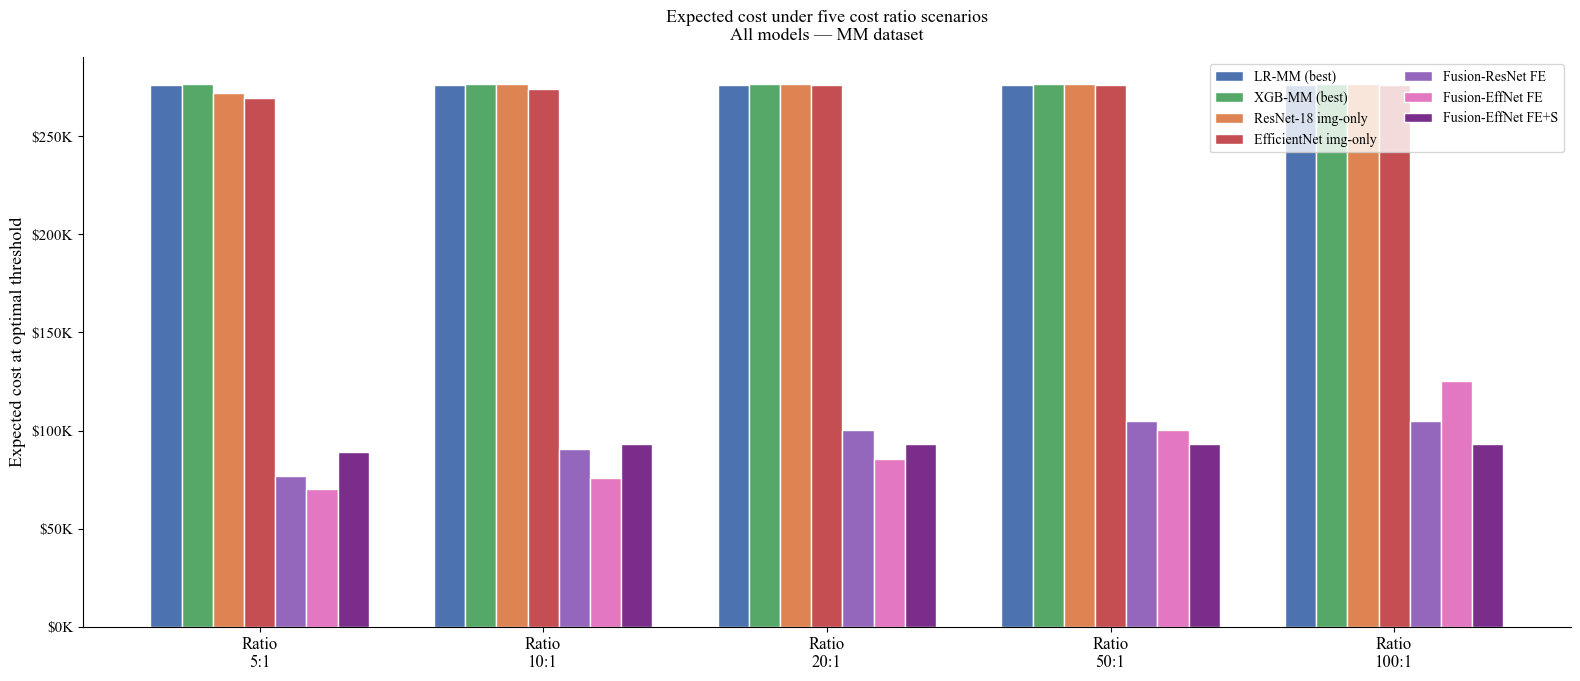

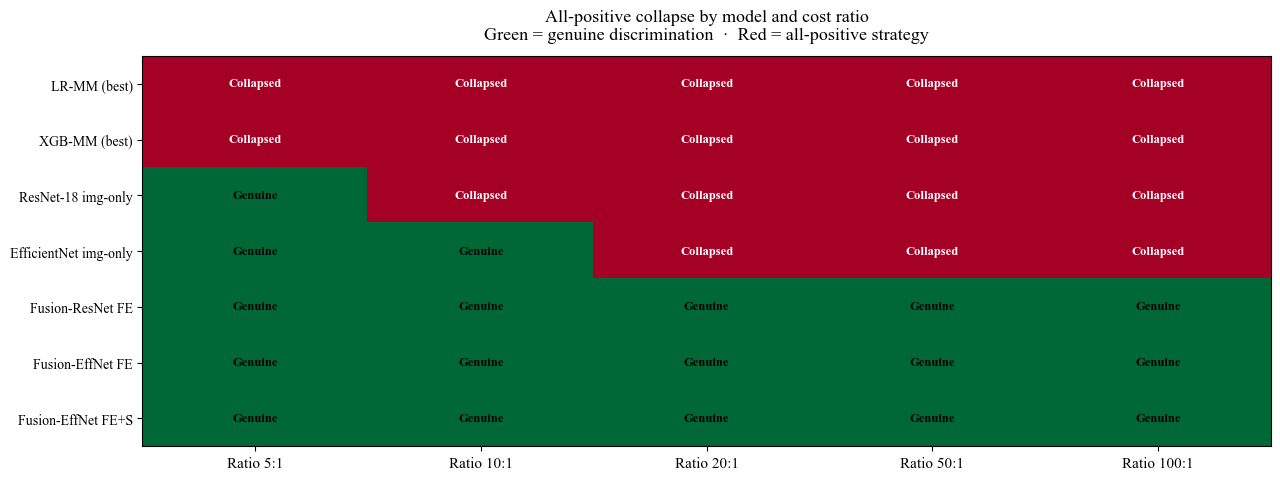

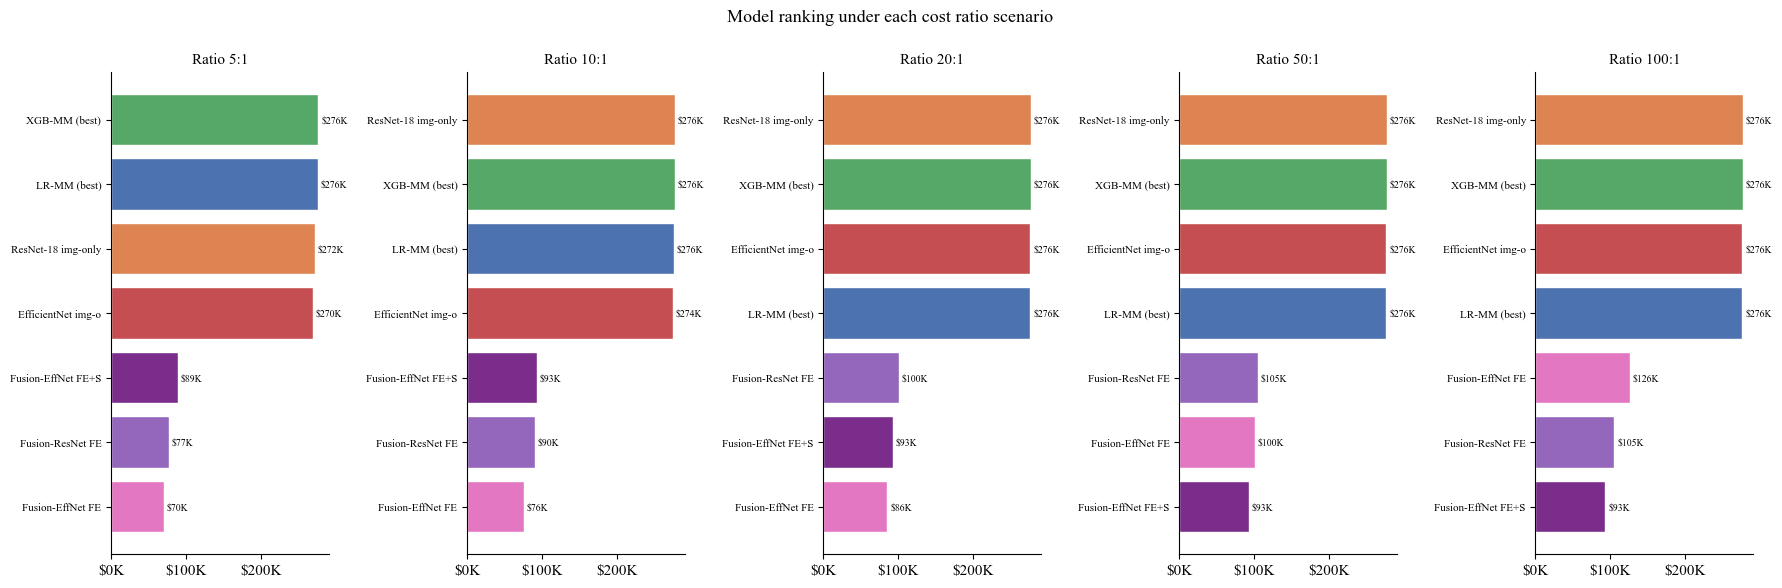


Does the multimodal model remain best under all ratios?
  Ratio 5:1     Best: Fusion-EffNet FE                Worst: XGB-MM (best)
  Ratio 10:1    Best: Fusion-EffNet FE                Worst: ResNet-18 img-only
  Ratio 20:1    Best: Fusion-EffNet FE                Worst: ResNet-18 img-only
  Ratio 50:1    Best: Fusion-EffNet FE+S              Worst: ResNet-18 img-only
  Ratio 100:1   Best: Fusion-EffNet FE+S              Worst: ResNet-18 img-only


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from sklearn.metrics import (confusion_matrix, precision_score,
                              recall_score, f1_score)

# ── Cost scenarios ────────────────────────────────────────────────────────────
cost_scenarios = {
    "5:1":   ( 2_500, 500),
    "10:1":  ( 5_000, 500),
    "20:1":  (10_000, 500),
    "50:1":  (25_000, 500),
    "100:1": (50_000, 500),
}

thresholds = np.arange(0.05, 1.00, 0.01)

# ── Models to compare ─────────────────────────────────────────────────────────
model_paths = {
    "LR-MM (best)":          R_NB/"mm_tabular_logreg"/"A_none",
    "XGB-MM (best)":         R_NB/"mm_tabular_xgboost"/"B_smote",
    "ResNet-18 img-only":    R_NB/"mm_image_resnet18"/"B_sampler",
    "EfficientNet img-only": R_NB/"mm_image_efficientnet_b0"/"B_sampler",
    "Fusion-ResNet FE":      R_NB/"mm_deep_resnet18"/"C_fe_normal",
    "Fusion-EffNet FE":      R_NB/"mm_deep_efficientnet_b0"/"C_fe_normal",
    "Fusion-EffNet FE+S":    R_NB/"mm_deep_efficientnet_b0"/"D_fe_sampler",
}

COLOURS_M = {
    "LR-MM (best)":          "#4C72B0",
    "XGB-MM (best)":         "#55A868",
    "ResNet-18 img-only":    "#DD8452",
    "EfficientNet img-only": "#C44E52",
    "Fusion-ResNet FE":      "#9467BD",
    "Fusion-EffNet FE":      "#E377C2",
    "Fusion-EffNet FE+S":    "#7B2D8B",
}

# ── Load predictions and compute optimal cost per ratio ───────────────────────
sensitivity_rows = []

for model_name, model_path in model_paths.items():
    pred_path = model_path / "test_predictions.csv"
    try:
        pred_df = pd.read_csv(pred_path)
    except FileNotFoundError:
        print(f"  Missing: {pred_path}")
        continue

    yt = pred_df["y_true"].values
    yp = pred_df["y_prob"].values

    for ratio_label, (fn_c, fp_c) in cost_scenarios.items():
        best_cost = np.inf
        best_row  = None
        for t in thresholds:
            y_pred = (yp >= t).astype(int)
            cm     = confusion_matrix(yt, y_pred, labels=[0,1])
            tn, fp, fn, tp = cm.ravel()
            cost = fn * fn_c + fp * fp_c
            if cost < best_cost:
                best_cost = cost
                best_row  = {
                    "model":     model_name,
                    "ratio":     ratio_label,
                    "fn_cost":   fn_c,
                    "fp_cost":   fp_c,
                    "threshold": round(t, 3),
                    "tn": int(tn), "fp": int(fp),
                    "fn": int(fn), "tp": int(tp),
                    "precision": float(precision_score(yt, (yp>=t).astype(int),
                                                       zero_division=0)),
                    "recall":    float(recall_score(yt, (yp>=t).astype(int),
                                                    zero_division=0)),
                    "f1":        float(f1_score(yt, (yp>=t).astype(int),
                                                zero_division=0)),
                    "cost":      int(best_cost),
                    "collapsed": int(tn) <= 5,
                }
        if best_row:
            sensitivity_rows.append(best_row)

sens_df = pd.DataFrame(sensitivity_rows)
print("Sensitivity analysis complete.")
print(sens_df[["model","ratio","threshold","tn","fp","fn",
               "precision","recall","cost","collapsed"
               ]].to_string(index=False))

# ── Plot 1: expected cost per model per ratio ─────────────────────────────────
plt.close("all")
plt.rcParams.update({
    "font.family":      "Times New Roman",
    "font.size":        13,
    "axes.titlesize":   13,
    "axes.labelsize":   13,
    "xtick.labelsize":  11,
    "ytick.labelsize":  11,
    "legend.fontsize":  10,
})

ratio_labels = list(cost_scenarios.keys())
models       = list(model_paths.keys())

x  = np.arange(len(ratio_labels))
n  = len(models)
w  = 0.11
offsets = np.linspace(-(n-1)/2*w, (n-1)/2*w, n)

fig, ax = plt.subplots(figsize=(16, 7))

for i, model_name in enumerate(models):
    df_m = sens_df[sens_df["model"] == model_name]
    if df_m.empty:
        continue
    costs = [df_m[df_m["ratio"] == r]["cost"].values[0]
             if r in df_m["ratio"].values else np.nan
             for r in ratio_labels]
    ax.bar(x + offsets[i], costs, w,
           label=model_name,
           color=COLOURS_M.get(model_name, "#888"),
           edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels([f"Ratio\n{r}" for r in ratio_labels], fontsize=12)
ax.yaxis.set_major_formatter(FuncFormatter(
    lambda v,_: f"${v/1_000:.0f}K" if v < 1_000_000 else f"${v/1e6:.2f}M"))
ax.set_ylabel("Expected cost at optimal threshold")
ax.set_title("Expected cost under five cost ratio scenarios\n"
             "All models — MM dataset", pad=12)
ax.legend(fontsize=10, loc="upper right", ncol=2)
ax.spines[["top","right"]].set_visible(False)

fig.tight_layout()
fig.savefig(FIG_DIR/"sensitivity_all_models_cost.png",
            dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 2: does model collapse under each ratio? ─────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

collapse_matrix = np.zeros((len(models), len(ratio_labels)))
for i, model_name in enumerate(models):
    for j, ratio in enumerate(ratio_labels):
        row = sens_df[(sens_df["model"]==model_name) &
                      (sens_df["ratio"]==ratio)]
        if not row.empty:
            collapse_matrix[i, j] = 1 if row.iloc[0]["collapsed"] else 0

im = ax.imshow(collapse_matrix, cmap="RdYlGn_r", vmin=0, vmax=1,
               aspect="auto")

for i in range(len(models)):
    for j in range(len(ratio_labels)):
        val = collapse_matrix[i, j]
        txt = "Collapsed" if val == 1 else "Genuine"
        clr = "white" if val == 1 else "black"
        ax.text(j, i, txt, ha="center", va="center",
                fontsize=9, color=clr, fontweight="bold")

ax.set_xticks(range(len(ratio_labels)))
ax.set_xticklabels([f"Ratio {r}" for r in ratio_labels], fontsize=11)
ax.set_yticks(range(len(models)))
ax.set_yticklabels(models, fontsize=10)
ax.set_title("All-positive collapse by model and cost ratio\n"
             "Green = genuine discrimination  ·  Red = all-positive strategy",
             pad=12)

fig.tight_layout()
fig.savefig(FIG_DIR/"sensitivity_collapse_matrix.png",
            dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 3: model ranking by cost under each ratio ────────────────────────────
fig, axes = plt.subplots(1, len(ratio_labels), figsize=(18, 6), sharey=False)

for ax, ratio in zip(axes, ratio_labels):
    df_r = sens_df[sens_df["ratio"] == ratio].sort_values("cost")
    clrs = [COLOURS_M.get(m,"#888") for m in df_r["model"]]
    bars = ax.barh(range(len(df_r)), df_r["cost"],
                   color=clrs, edgecolor="white")
    ax.set_yticks(range(len(df_r)))
    ax.set_yticklabels([m[:18] for m in df_r["model"]], fontsize=8)
    ax.xaxis.set_major_formatter(FuncFormatter(
        lambda v,_: f"${v/1_000:.0f}K"))
    ax.set_title(f"Ratio {ratio}", fontsize=11)
    ax.spines[["top","right"]].set_visible(False)
    ax.bar_label(bars,
        labels=[f"${v/1_000:.0f}K" for v in df_r["cost"]],
        padding=2, fontsize=7)

fig.suptitle("Model ranking under each cost ratio scenario",
             fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR/"sensitivity_rankings.png",
            dpi=150, bbox_inches="tight")
plt.show()

plt.rcParams.update(plt.rcParamsDefault)

# ── Summary: does ranking change? ─────────────────────────────────────────────
print("\n" + "="*60)
print("Does the multimodal model remain best under all ratios?")
print("="*60)
for ratio in ratio_labels:
    df_r  = sens_df[sens_df["ratio"]==ratio].sort_values("cost")
    best  = df_r.iloc[0]["model"]
    worst = df_r.iloc[-1]["model"]
    print(f"  Ratio {ratio:<6}  Best: {best:<30}  Worst: {worst}")

Sensitivity analysis complete.
                model ratio  threshold  tn  fp  fn  precision   recall  cost  collapsed
         LR-MM (best)   5:1       0.18   2 552   0   0.625000 1.000000   552       True
         LR-MM (best)  10:1       0.18   2 552   0   0.625000 1.000000   552       True
         LR-MM (best)  20:1       0.18   2 552   0   0.625000 1.000000   552       True
         LR-MM (best)  50:1       0.18   2 552   0   0.625000 1.000000   552       True
         LR-MM (best) 100:1       0.18   2 552   0   0.625000 1.000000   552       True
        XGB-MM (best)   5:1       0.14   1 553   0   0.624576 1.000000   553       True
        XGB-MM (best)  10:1       0.14   1 553   0   0.624576 1.000000   553       True
        XGB-MM (best)  20:1       0.14   1 553   0   0.624576 1.000000   553       True
        XGB-MM (best)  50:1       0.14   1 553   0   0.624576 1.000000   553       True
        XGB-MM (best) 100:1       0.14   1 553   0   0.624576 1.000000   553       True
 

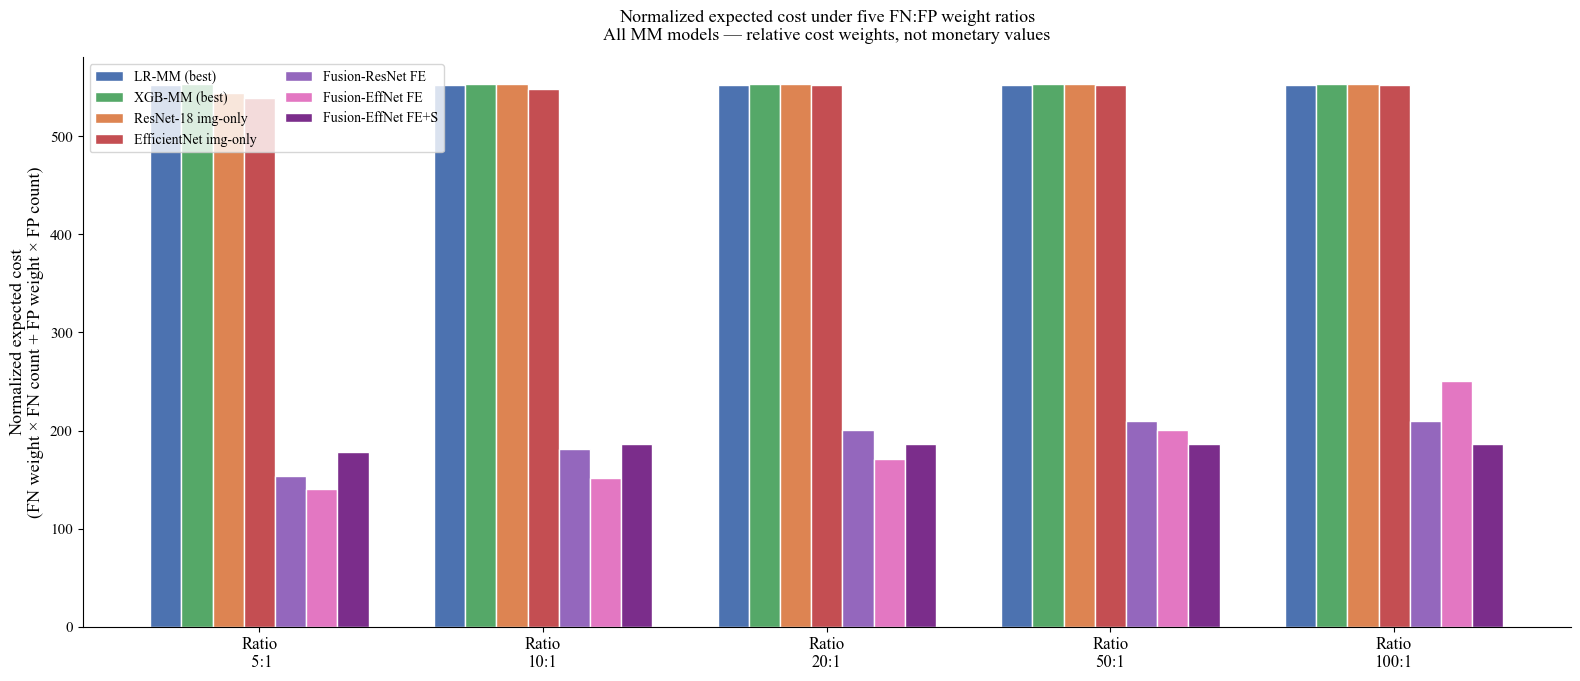

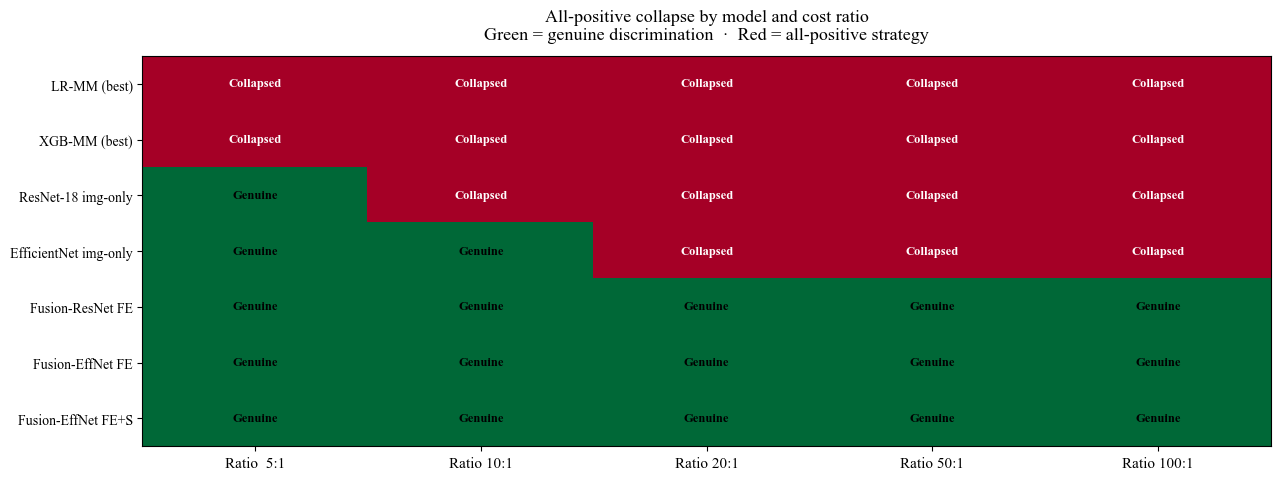

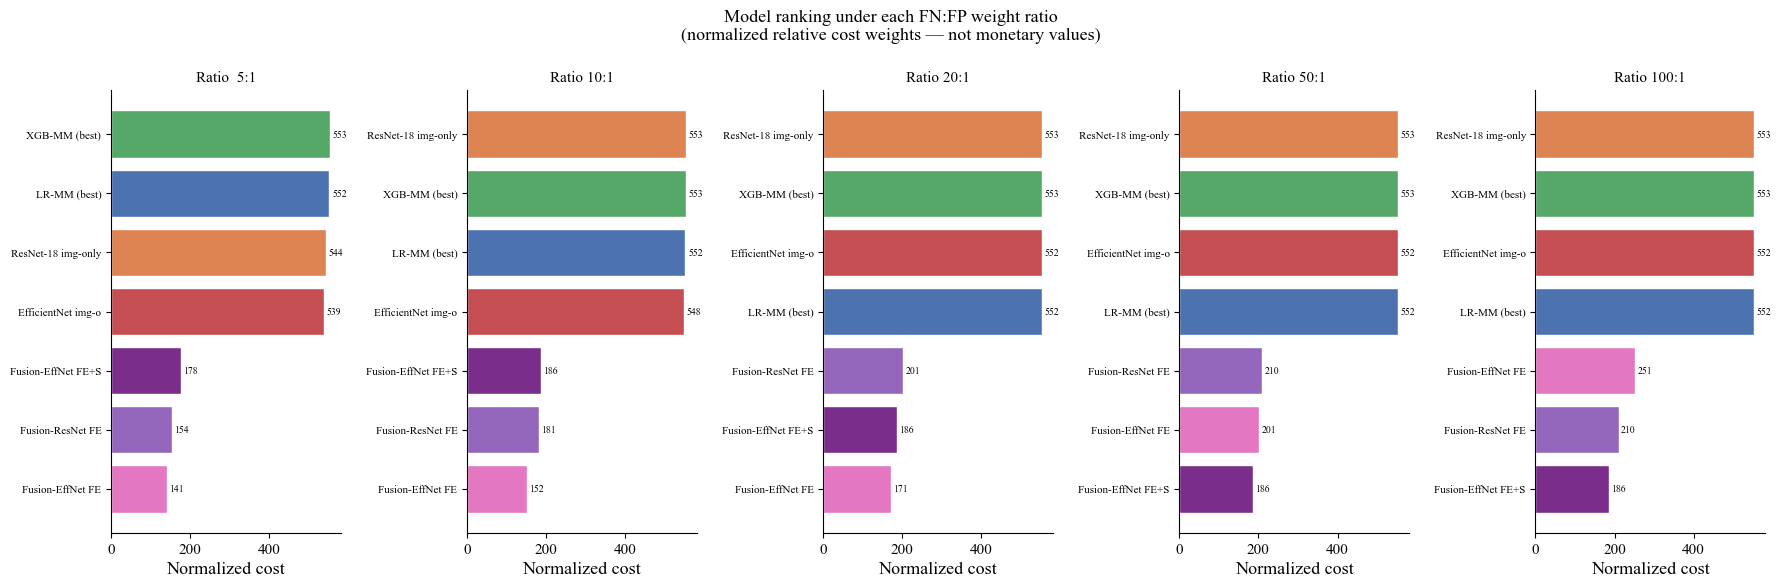


Does multimodal remain best across all weight ratios?
  Ratio  5:1     Best: Fusion-EffNet FE                Worst: XGB-MM (best)
  Ratio 10:1     Best: Fusion-EffNet FE                Worst: ResNet-18 img-only
  Ratio 20:1     Best: Fusion-EffNet FE                Worst: ResNet-18 img-only
  Ratio 50:1     Best: Fusion-EffNet FE+S              Worst: ResNet-18 img-only
  Ratio 100:1    Best: Fusion-EffNet FE+S              Worst: ResNet-18 img-only


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from sklearn.metrics import (confusion_matrix, precision_score,
                              recall_score, f1_score)

# ── Cost scenarios — relative weights, not dollar amounts ─────────────────────
# Following Elkan (2001): only relative costs matter for optimal decisions.
# FP weight fixed at 1, FN weight varies to reflect asymmetric error costs.
cost_scenarios = {
    " 5:1":  ( 5,  1),
    "10:1":  (10,  1),
    "20:1":  (20,  1),
    "50:1":  (50,  1),
    "100:1": (100, 1),
}

thresholds = np.arange(0.05, 1.00, 0.01)

# ── Models to compare ─────────────────────────────────────────────────────────
model_paths = {
    "LR-MM (best)":          R_NB/"mm_tabular_logreg"/"A_none",
    "XGB-MM (best)":         R_NB/"mm_tabular_xgboost"/"B_smote",
    "ResNet-18 img-only":    R_NB/"mm_image_resnet18"/"B_sampler",
    "EfficientNet img-only": R_NB/"mm_image_efficientnet_b0"/"B_sampler",
    "Fusion-ResNet FE":      R_NB/"mm_deep_resnet18"/"C_fe_normal",
    "Fusion-EffNet FE":      R_NB/"mm_deep_efficientnet_b0"/"C_fe_normal",
    "Fusion-EffNet FE+S":    R_NB/"mm_deep_efficientnet_b0"/"D_fe_sampler",
}

COLOURS_M = {
    "LR-MM (best)":          "#4C72B0",
    "XGB-MM (best)":         "#55A868",
    "ResNet-18 img-only":    "#DD8452",
    "EfficientNet img-only": "#C44E52",
    "Fusion-ResNet FE":      "#9467BD",
    "Fusion-EffNet FE":      "#E377C2",
    "Fusion-EffNet FE+S":    "#7B2D8B",
}

# ── Compute optimal weighted cost per model per ratio ─────────────────────────
sensitivity_rows = []

for model_name, model_path in model_paths.items():
    pred_path = model_path / "test_predictions.csv"
    try:
        pred_df = pd.read_csv(pred_path)
    except FileNotFoundError:
        print(f"  Missing: {pred_path}")
        continue

    yt = pred_df["y_true"].values
    yp = pred_df["y_prob"].values

    for ratio_label, (fn_w, fp_w) in cost_scenarios.items():
        best_cost = np.inf
        best_row  = None
        for t in thresholds:
            y_pred = (yp >= t).astype(int)
            cm     = confusion_matrix(yt, y_pred, labels=[0, 1])
            tn, fp, fn, tp = cm.ravel()
            cost = fn * fn_w + fp * fp_w   # normalized weight, not dollars
            if cost < best_cost:
                best_cost = cost
                best_row  = {
                    "model":     model_name,
                    "ratio":     ratio_label,
                    "fn_weight": fn_w,
                    "fp_weight": fp_w,
                    "threshold": round(t, 3),
                    "tn": int(tn), "fp": int(fp),
                    "fn": int(fn), "tp": int(tp),
                    "precision": float(precision_score(yt, (yp>=t).astype(int),
                                                       zero_division=0)),
                    "recall":    float(recall_score(yt, (yp>=t).astype(int),
                                                    zero_division=0)),
                    "f1":        float(f1_score(yt, (yp>=t).astype(int),
                                                zero_division=0)),
                    "cost":      int(best_cost),
                    "collapsed": int(tn) <= 5,
                }
        if best_row:
            sensitivity_rows.append(best_row)

sens_df = pd.DataFrame(sensitivity_rows)
print("Sensitivity analysis complete.")
print(sens_df[["model","ratio","threshold","tn","fp","fn",
               "precision","recall","cost","collapsed"
               ]].to_string(index=False))

# ── Plot 1: normalized expected cost per model per ratio ──────────────────────
plt.close("all")
plt.rcParams.update({
    "font.family":      "Times New Roman",
    "font.size":        13,
    "axes.titlesize":   13,
    "axes.labelsize":   13,
    "xtick.labelsize":  11,
    "ytick.labelsize":  11,
    "legend.fontsize":  10,
})

ratio_labels = list(cost_scenarios.keys())
models       = list(model_paths.keys())
x  = np.arange(len(ratio_labels))
n  = len(models)
w  = 0.11
offsets = np.linspace(-(n-1)/2*w, (n-1)/2*w, n)

fig, ax = plt.subplots(figsize=(16, 7))
for i, model_name in enumerate(models):
    df_m = sens_df[sens_df["model"] == model_name]
    if df_m.empty:
        continue
    costs = [df_m[df_m["ratio"] == r]["cost"].values[0]
             if r in df_m["ratio"].values else np.nan
             for r in ratio_labels]
    ax.bar(x + offsets[i], costs, w,
           label=model_name,
           color=COLOURS_M.get(model_name, "#888"),
           edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels([f"Ratio\n{r}" for r in ratio_labels], fontsize=12)
ax.set_ylabel("Normalized expected cost\n(FN weight × FN count + FP weight × FP count)")
ax.set_title("Normalized expected cost under five FN:FP weight ratios\n"
             "All MM models — relative cost weights, not monetary values",
             pad=12)
ax.legend(fontsize=10, loc="upper left", ncol=2)
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR/"sensitivity_all_models_cost.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 2: collapse matrix ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
collapse_matrix = np.zeros((len(models), len(ratio_labels)))
for i, model_name in enumerate(models):
    for j, ratio in enumerate(ratio_labels):
        row = sens_df[(sens_df["model"]==model_name) &
                      (sens_df["ratio"]==ratio)]
        if not row.empty:
            collapse_matrix[i, j] = 1 if row.iloc[0]["collapsed"] else 0

ax.imshow(collapse_matrix, cmap="RdYlGn_r", vmin=0, vmax=1, aspect="auto")
for i in range(len(models)):
    for j in range(len(ratio_labels)):
        val = collapse_matrix[i, j]
        ax.text(j, i, "Collapsed" if val == 1 else "Genuine",
                ha="center", va="center", fontsize=9,
                color="white" if val == 1 else "black", fontweight="bold")

ax.set_xticks(range(len(ratio_labels)))
ax.set_xticklabels([f"Ratio {r}" for r in ratio_labels], fontsize=11)
ax.set_yticks(range(len(models)))
ax.set_yticklabels(models, fontsize=10)
ax.set_title("All-positive collapse by model and cost ratio\n"
             "Green = genuine discrimination  ·  Red = all-positive strategy",
             pad=12)
fig.tight_layout()
fig.savefig(FIG_DIR/"sensitivity_collapse_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 3: model ranking per ratio ──────────────────────────────────────────
fig, axes = plt.subplots(1, len(ratio_labels), figsize=(18, 6))
for ax, ratio in zip(axes, ratio_labels):
    df_r = sens_df[sens_df["ratio"] == ratio].sort_values("cost")
    bars = ax.barh(range(len(df_r)), df_r["cost"],
                   color=[COLOURS_M.get(m,"#888") for m in df_r["model"]],
                   edgecolor="white")
    ax.set_yticks(range(len(df_r)))
    ax.set_yticklabels([m[:18] for m in df_r["model"]], fontsize=8)
    ax.set_title(f"Ratio {ratio}", fontsize=11)
    ax.set_xlabel("Normalized cost")
    ax.bar_label(bars, labels=[str(v) for v in df_r["cost"]],
                 padding=2, fontsize=7)
    ax.spines[["top","right"]].set_visible(False)

fig.suptitle("Model ranking under each FN:FP weight ratio\n"
             "(normalized relative cost weights — not monetary values)",
             fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR/"sensitivity_rankings.png", dpi=150, bbox_inches="tight")
plt.show()

plt.rcParams.update(plt.rcParamsDefault)

# ── Summary ───────────────────────────────────────────────────────────────────
print("\n" + "="*65)
print("Does multimodal remain best across all weight ratios?")
print("="*65)
for ratio in ratio_labels:
    df_r  = sens_df[sens_df["ratio"]==ratio].sort_values("cost")
    if df_r.empty: continue
    best  = df_r.iloc[0]["model"]
    worst = df_r.iloc[-1]["model"]
    print(f"  Ratio {ratio:<7}  Best: {best:<30}  Worst: {worst}")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

plt.close("all")
plt.rcParams.update({
    "font.family":      "Times New Roman",
    "font.size":        13,
    "axes.titlesize":   13,
    "axes.labelsize":   13,
    "xtick.labelsize":  11,
    "ytick.labelsize":  11,
    "legend.fontsize":  10,
})

# ── Cost weights ──────────────────────────────────────────────────────────────
def weighted_cost(fn, fp, fn_w, fp_w):
    return int(fn * fn_w + fp * fp_w)

cost_ratios = {
    " 5:1":  ( 5, 1),
    "10:1":  (10, 1),
    "20:1":  (20, 1),
    "50:1":  (50, 1),
    "100:1": (100,1),
}

MAIN_RATIO   = "10:1"
MAIN_FN_W, MAIN_FP_W = cost_ratios[MAIN_RATIO]

COLOURS_M = {
    "LR-MM":               "#4C72B0",
    "XGB-MM":              "#55A868",
    "ResNet-18 img-only":  "#DD8452",
    "EfficientNet img-only":"#C44E52",
    "Fusion-ResNet FE":    "#9467BD",
    "Fusion-EffNet FE":    "#E377C2",
    "Fusion-EffNet FE+S":  "#7B2D8B",
}

# ── sens_df must already be computed from the sensitivity analysis ─────────────
# (re-run that cell first if needed)
assert "sens_df" in dir(), "Run the sensitivity analysis cell first."

# Normalise model names for display
name_map = {
    "LR-MM (best)":          "LR-MM",
    "XGB-MM (best)":         "XGB-MM",
    "ResNet-18 img-only":    "ResNet-18 img-only",
    "EfficientNet img-only": "EfficientNet img-only",
    "Fusion-ResNet FE":      "Fusion-ResNet FE",
    "Fusion-EffNet FE":      "Fusion-EffNet FE",
    "Fusion-EffNet FE+S":    "Fusion-EffNet FE+S",
}
sens_df["model_short"] = sens_df["model"].map(name_map).fillna(sens_df["model"])

# ── TABLE 1: sensitivity across all ratios ────────────────────────────────────
print("="*100)
print("TABLE 1 — Sensitivity analysis across cost ratios")
print("="*100)
t1 = sens_df[["model_short","ratio","threshold","tn","fp","fn",
               "precision","recall","cost","collapsed"]].copy()
t1.columns = ["Model","Ratio","Threshold","TN","FP","FN",
               "Precision","Recall","Weighted cost","Collapsed"]
t1["Precision"] = t1["Precision"].round(4)
t1["Recall"]    = t1["Recall"].round(4)
print(t1.to_string(index=False))
t1.to_csv(FIG_DIR/"table1_sensitivity.csv", index=False)

# ── TABLE 2: final comparison at 10:1 with reduction vs best unimodal ─────────
df_main = sens_df[sens_df["ratio"] == MAIN_RATIO].copy()
df_main["model_short"] = df_main["model"].map(name_map).fillna(df_main["model"])

# Best unimodal = lowest cost among non-fusion models at 10:1
unimodal_mask = ~df_main["model_short"].str.startswith("Fusion")
baseline_cost = df_main[unimodal_mask]["cost"].min()

df_main["Reduction vs best unimodal (%)"] = (
    (baseline_cost - df_main["cost"]) / baseline_cost * 100
).round(1)

t2 = df_main[["model_short","threshold","precision","recall",
               "tn","fp","fn","cost",
               "Reduction vs best unimodal (%)","collapsed"]].copy()
t2.columns = ["Model","Threshold","Precision","Recall",
               "TN","FP","FN","Weighted cost",
               "Reduction vs best unimodal (%)","Collapsed"]
t2["Precision"] = t2["Precision"].round(4)
t2["Recall"]    = t2["Recall"].round(4)
t2 = t2.sort_values("Weighted cost").reset_index(drop=True)

print()
print("="*100)
print(f"TABLE 2 — Final comparison at {MAIN_RATIO} cost ratio")
print(f"Baseline (best unimodal) weighted cost: {baseline_cost}")
print("="*100)
print(t2.to_string(index=False))
t2.to_csv(FIG_DIR/"table2_comparison_10_1.csv", index=False)

# ════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Bar chart: weighted cost at 10:1
# ════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(13, 6))

clrs  = [COLOURS_M.get(m, "#888") for m in t2["Model"]]
bars  = ax.bar(range(len(t2)), t2["Weighted cost"],
               color=clrs, edgecolor="white", width=0.6)

ax.bar_label(bars, labels=[str(v) for v in t2["Weighted cost"]],
             padding=4, fontsize=12, fontweight="bold")

# Annotate reduction for fusion models
for i, row in t2.iterrows():
    if row["Model"].startswith("Fusion") and row["Reduction vs best unimodal (%)"] > 0:
        ax.text(i, row["Weighted cost"] + max(t2["Weighted cost"]) * 0.04,
                f"-{row['Reduction vs best unimodal (%)']:.0f}%",
                ha="center", fontsize=10, color="#2d6a2d",
                fontweight="bold", style="italic")

ax.set_xticks(range(len(t2)))
ax.set_xticklabels(t2["Model"], rotation=20, ha="right", fontsize=11)
ax.set_ylabel(f"Weighted misclassification cost\n(FN × {MAIN_FN_W} + FP × {MAIN_FP_W})")
ax.set_title(f"Weighted misclassification cost at the {MAIN_RATIO} cost ratio\n"
             "Lower values indicate better cost-sensitive performance")
ax.axhline(baseline_cost, color="gray", linestyle="--", lw=1.2, alpha=0.6,
           label=f"Best unimodal baseline ({baseline_cost})")
ax.legend(fontsize=10)
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR/"fig_weighted_cost_10_1.png", dpi=150, bbox_inches="tight")
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Line plot: sensitivity across ratios
# ════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(12, 6))

for model_short in sens_df["model_short"].unique():
    df_m = sens_df[sens_df["model_short"] == model_short].sort_values("ratio")
    costs = df_m["cost"].values
    ax.plot(range(len(cost_ratios)), costs,
            marker="o", lw=2.2, markersize=6,
            color=COLOURS_M.get(model_short, "#888"),
            label=model_short)

ax.set_xticks(range(len(cost_ratios)))
ax.set_xticklabels(list(cost_ratios.keys()), fontsize=11)
ax.set_xlabel("FN:FP cost ratio")
ax.set_ylabel("Weighted misclassification cost")
ax.set_title("Sensitivity of weighted misclassification cost\n"
             "to different false-negative to false-positive ratios")
ax.legend(fontsize=9, loc="upper left", ncol=2)
ax.spines[["top","right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR/"fig_sensitivity_line.png", dpi=150, bbox_inches="tight")
plt.show()

# ════════════════════════════════════════════════════════════════════════════
# FIGURE 3 — Confusion matrices at 10:1 (best tabular, image-only, fusion)
# ════════════════════════════════════════════════════════════════════════════
# Pick best of each group at 10:1
group_best = {
    "Best tabular\n(XGB-MM)":          "XGB-MM",
    "Best image-only\n(EfficientNet)":  "EfficientNet img-only",
    "Best fusion\n(Fusion-EffNet FE)":  "Fusion-EffNet FE",
}

model_paths_fig3 = {
    "XGB-MM":              R_NB/"mm_tabular_xgboost"/"B_smote",
    "EfficientNet img-only":R_NB/"mm_image_efficientnet_b0"/"B_sampler",
    "Fusion-EffNet FE":    R_NB/"mm_deep_efficientnet_b0"/"C_fe_normal",
}

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, (panel_title, model_short) in zip(axes, group_best.items()):
    folder  = model_paths_fig3[model_short]
    df_row  = df_main[df_main["model_short"] == model_short]

    if df_row.empty:
        ax.axis("off"); continue

    row = df_row.iloc[0]
    t   = row["threshold"]

    try:
        pred_df = pd.read_csv(folder / "test_predictions.csv")
    except FileNotFoundError:
        ax.axis("off"); continue

    yt     = pred_df["y_true"].values
    yp     = pred_df["y_prob"].values
    y_pred = (yp >= t).astype(int)
    cm     = confusion_matrix(yt, y_pred, labels=[0,1])
    tn, fp, fn, tp_ = cm.ravel()
    wc = weighted_cost(fn, fp, MAIN_FN_W, MAIN_FP_W)

    ConfusionMatrixDisplay(cm, display_labels=["Legit","Fraud"]).plot(
        ax=ax, colorbar=False, values_format="d", cmap="Blues")

    ax.set_title(f"{panel_title}\nt = {t:.2f}", fontsize=11, pad=8)
    ax.set_xlabel(
        f"TN={tn}  FP={fp}  FN={fn}\n"
        f"Weighted cost = {fn}×{MAIN_FN_W} + {fp}×{MAIN_FP_W} = {wc}",
        fontsize=9)

fig.suptitle(f"Confusion matrices at the {MAIN_RATIO} cost ratio\n"
             "Best model per group — tabular, image-only, and fusion",
             fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR/"fig_confusion_matrices_10_1.png", dpi=150, bbox_inches="tight")
plt.show()

plt.rcParams.update(plt.rcParamsDefault)

# ── Key result sentence for thesis ────────────────────────────────────────────
best_fusion = t2[t2["Model"].str.startswith("Fusion")].iloc[0]
best_uni    = t2[~t2["Model"].str.startswith("Fusion")].iloc[0]

print()
print("="*70)
print("KEY RESULT SENTENCE FOR THESIS:")
print("="*70)
print(
    f"The best-performing fusion model ({best_fusion['Model']}) achieved a "
    f"weighted misclassification cost of {best_fusion['Weighted cost']} "
    f"under the {MAIN_RATIO} cost ratio, compared with {best_uni['Weighted cost']} "
    f"for the best unimodal baseline ({best_uni['Model']}). "
    f"This corresponds to a {best_fusion['Reduction vs best unimodal (%)']:.1f}% "
    f"reduction in weighted cost relative to the best unimodal alternative."
)

AssertionError: Run the sensitivity analysis cell first.